In [1]:
from pathlib import Path
import sys

parent_dir = '..'
sys.path.append(parent_dir)

In [2]:
from utils import plot_silhouette

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
import seaborn.objects as so
from seaborn import axes_style

In [4]:
import stumpy
from stumpy import core
from sktime.transformations.panel.matrix_profile import MatrixProfile
from outliers import smirnov_grubbs as grubbs
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sklearn.cluster import AgglomerativeClustering, OPTICS, cluster_optics_dbscan
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [5]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted', rc={'figure.figsize': (12, 6)})
theme_dict = {**axes_style('whitegrid'), 'context': 'notebook', 'palette': 'muted'}
so.Plot.config.theme.update(theme_dict)

In [6]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')

In [7]:
train_X = train[[str(i) for i in range(100)]]
train_X = train_X.reset_index().melt(id_vars='id', var_name='time')
train_X['time'] = train_X['time'].astype(int)
train_X = train_X.set_index(['id', 'time'])

In [8]:
shape_medoids = ['tt7605074', 'tt1392190', 'tt2024544', 'tt0810819']
structure_medoids = ['tt2024544', 'tt1798709', 'tt3416828', 'tt1179933']
density_based_medoids = ['tt7131622', 'tt1798603', 'tt7984734', 'tt2170299', 'tt14444726']

In [9]:
train.iloc[:, :12].loc[shape_medoids]

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,awards,nominations,rating,genre,rating_category,totalGrossIncome
id,,,,,,,,,,,,
tt7605074,The Wandering Earth,2019,125,38453,['CN'],True,39.0,40.0,5.9,"['Action', 'Adventure', 'Sci-Fi']",Medium,11715373.0
tt1392190,Mad Max: Fury Road,2015,120,1177539,"['AU', 'US']",True,245.0,234.0,8.1,"['Action', 'Adventure', 'Sci-Fi']",High,289773789.0
tt2024544,12 Years a Slave,2013,134,770412,"['GB', 'US']",True,244.0,338.0,8.1,"['Biography', 'Drama', 'History']",High,69357605.0
tt0810819,The Danish Girl,2015,119,204330,"['GB', 'US', 'DE', 'DK', 'BE', 'JP']",True,32.0,82.0,7.1,"['Biography', 'Drama']",High,16716240.0


## Visualize motifs and discords on clustering medoids

In [10]:
def get_title(movie_id):
    title = train.loc[movie_id, 'title']
    year = train.loc[movie_id, 'startYear']
    return f'{title} ({year})'

We inspected results for different values of m, considering the periodicity of about two weeks.

In [11]:
m = 6

In [12]:
transformer = MatrixProfile(m=m)

In [13]:
%%time
mp = transformer.fit_transform(train_X)

CPU times: user 12.9 s, sys: 29.3 ms, total: 13 s
Wall time: 13 s


In [14]:
mp.index = train.index
mp.shape

(850, 95)

We consider discords only sequences classified as outliers in the profile matrix by a one sided grubb's test.

In [15]:
def get_discords(matrix_profile, alpha=0.05):
    """Detect candidate discords performing one-sided Grubb's test on matrix profile"""
    return grubbs.max_test_indices(matrix_profile, alpha=alpha)

In [16]:
def plot_ts_and_matrix_profile(movie_id):
    _, axs = plt.subplots(2, sharex=True)

    ts = train_X.loc[movie_id].value
    matrix = mp.loc[movie_id]

    # Plot raw time series
    axs[0].plot(ts)
    axs[0].set_title(get_title(movie_id))
    axs[0].set_ylabel('Box office')

    # Plot matrix profile
    axs[1].plot(matrix)
    axs[1].set_ylabel('Matrix Profile')
    plt.xticks(np.arange(0, 100, 7))

    plt.xlim((0, len(ts)))

    return axs

In [17]:
def plot_motifs(movie_id, axs, max_motifs=1, normalize=True):
    matrix = mp.loc[movie_id]
    ts = train_X.loc[movie_id]['value']
    bottom, top = axs[0].get_ylim()
    height = top - bottom

    _, motif_idxs = stumpy.motifs(ts, matrix, max_motifs=max_motifs, normalize=normalize)

    for i, motif in enumerate(motif_idxs):
        color = 'C2' if max_motifs <= 1 else f'C{i}'
        for starttime in motif:
            rect = Rectangle((starttime, bottom), m-1, height, facecolor=color, alpha=.5)
            axs[0].add_patch(rect)


In [18]:
def plot_discords(movie_id, axs):
    matrix = mp.loc[movie_id].values
    bottom, top = axs[0].get_ylim()
    height = top - bottom

    discords = get_discords(matrix)

    for starttime in discords:
        rect = Rectangle((starttime, bottom), m-1, height, facecolor='r', alpha=.5)
        axs[0].add_patch(rect)
        axs[1].axvline(x=starttime, linestyle='dashed', c='r')

### Shape-based clustering medoids

#### Hierarchical

/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/stumpy/motifs.py:380: UserWarning: No motifs were found. You may consider increasing the `cutoff` (e.g., cutoff=0.3384114145891625) and/or increasing the `max_distance `(e.g., max_distance=np.inf).
  warnings.warn(msg)


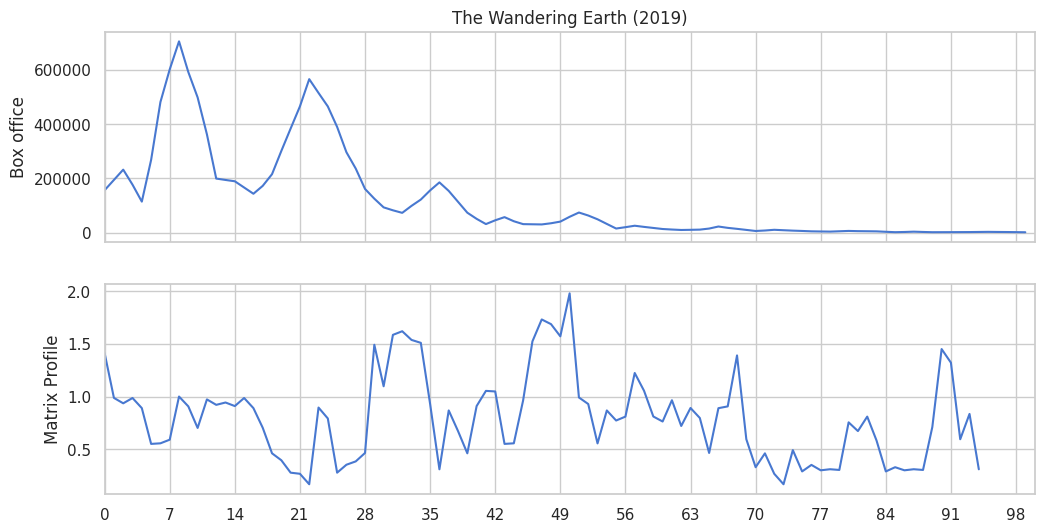

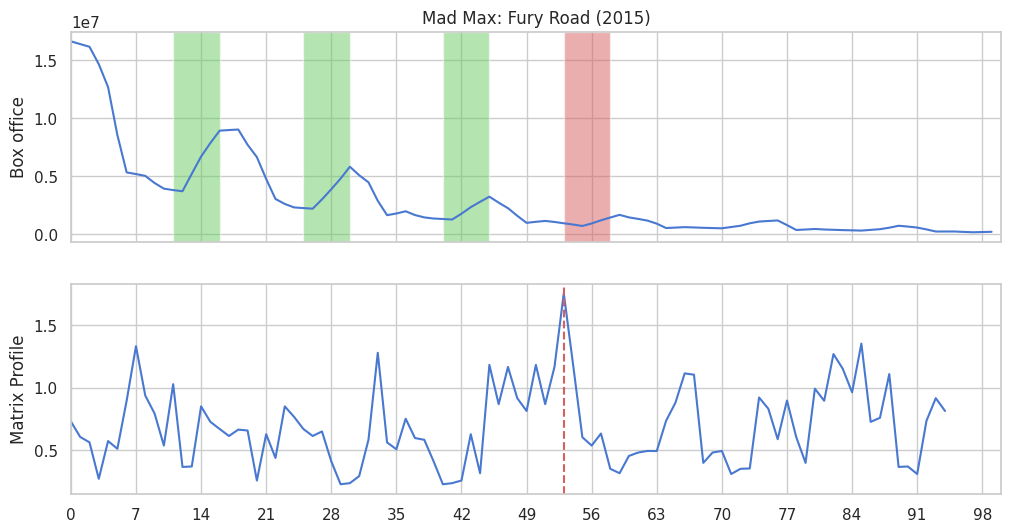

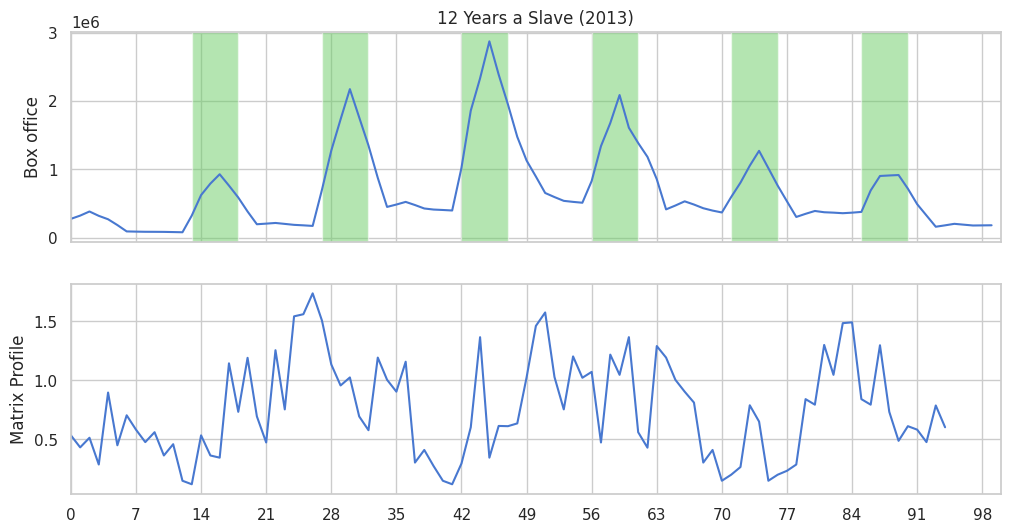

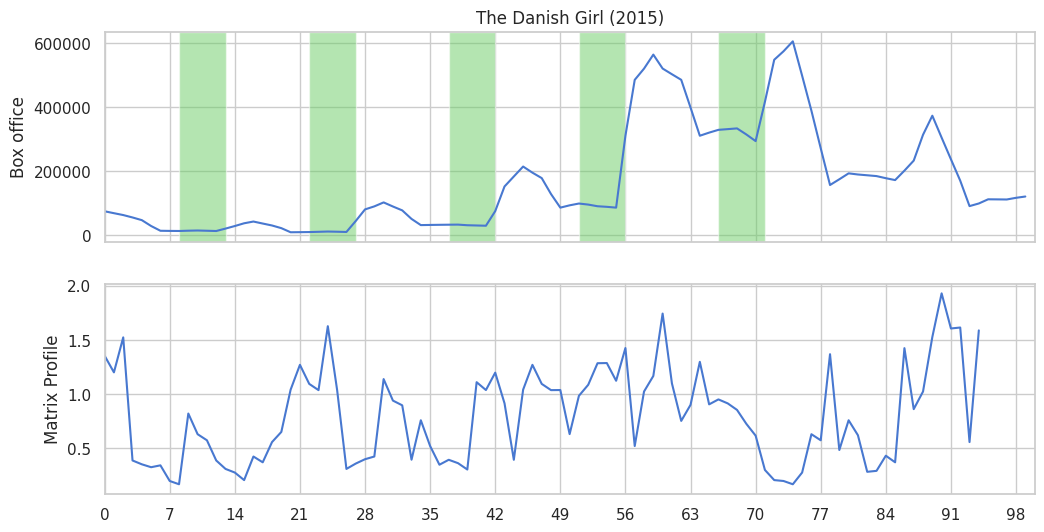

In [19]:
for movie_id in shape_medoids:
    axs = plot_ts_and_matrix_profile(movie_id)
    plot_motifs(movie_id, axs)
    plot_discords(movie_id, axs)
    plt.show()

#### Density based

/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/stumpy/motifs.py:380: UserWarning: No motifs were found. You may consider increasing the `cutoff` (e.g., cutoff=0.34407840785145927) and/or increasing the `max_distance `(e.g., max_distance=np.inf).
  warnings.warn(msg)


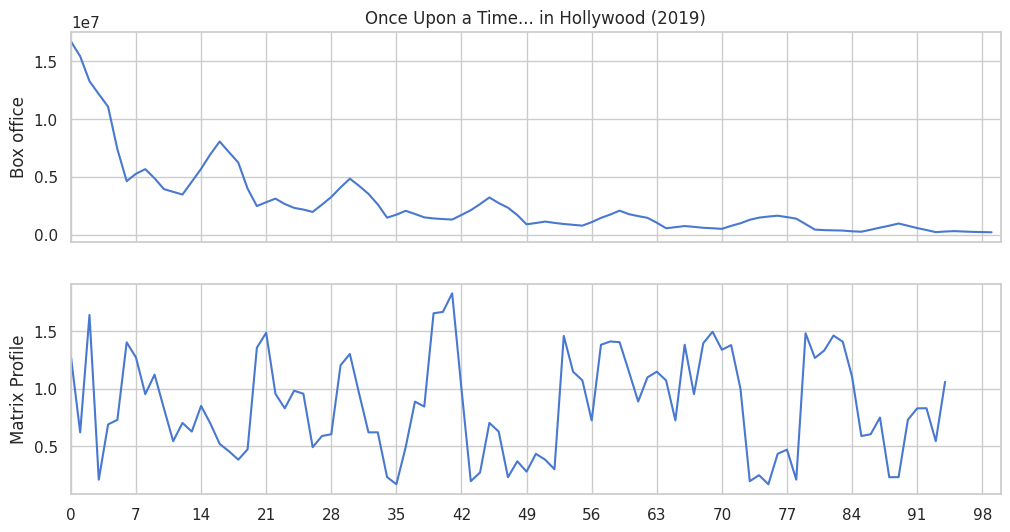

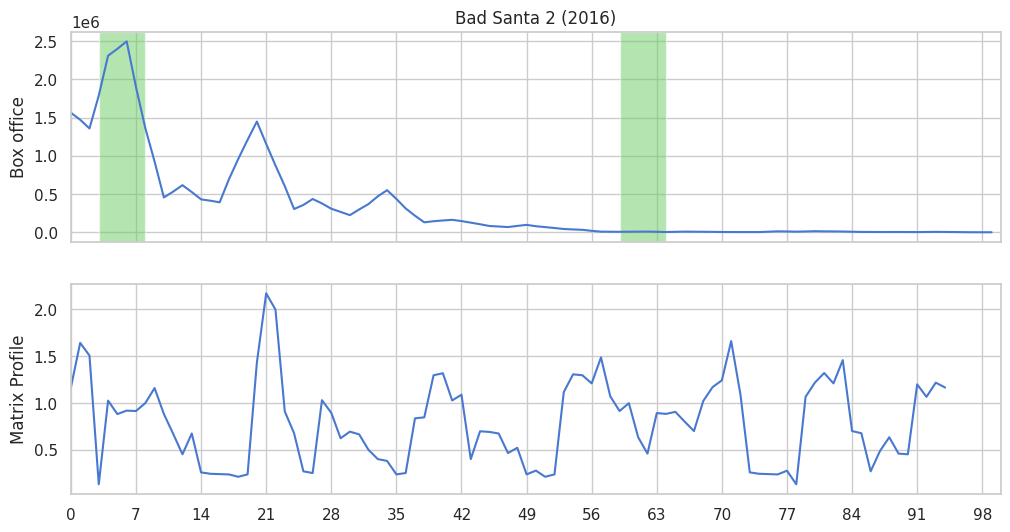

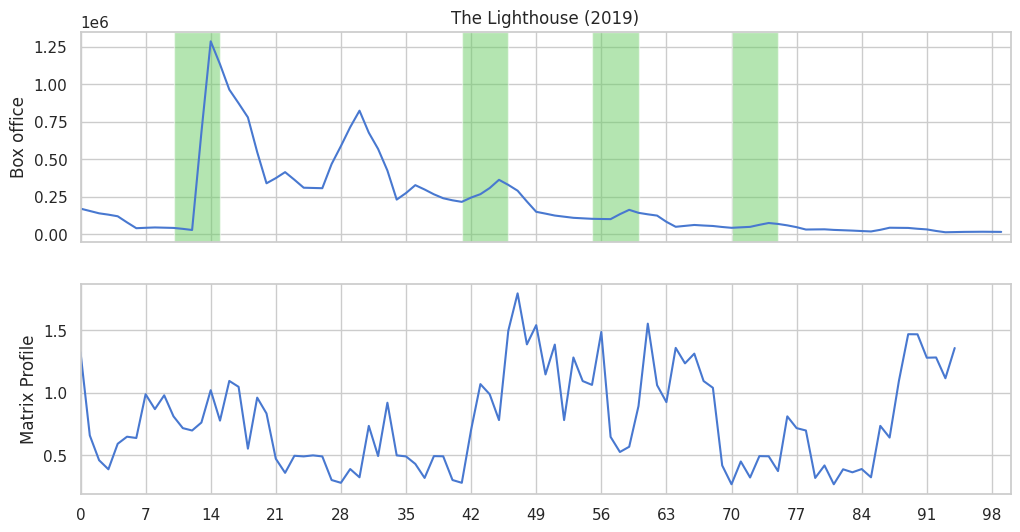

/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/stumpy/motifs.py:380: UserWarning: No motifs were found. You may consider increasing the `cutoff` (e.g., cutoff=0.29022769298492807) and/or increasing the `max_distance `(e.g., max_distance=np.inf).
  warnings.warn(msg)


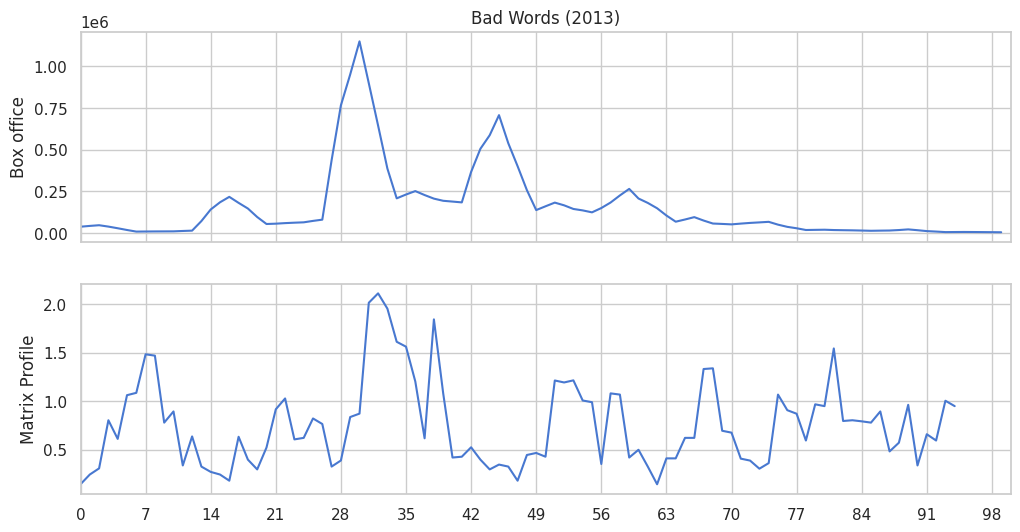

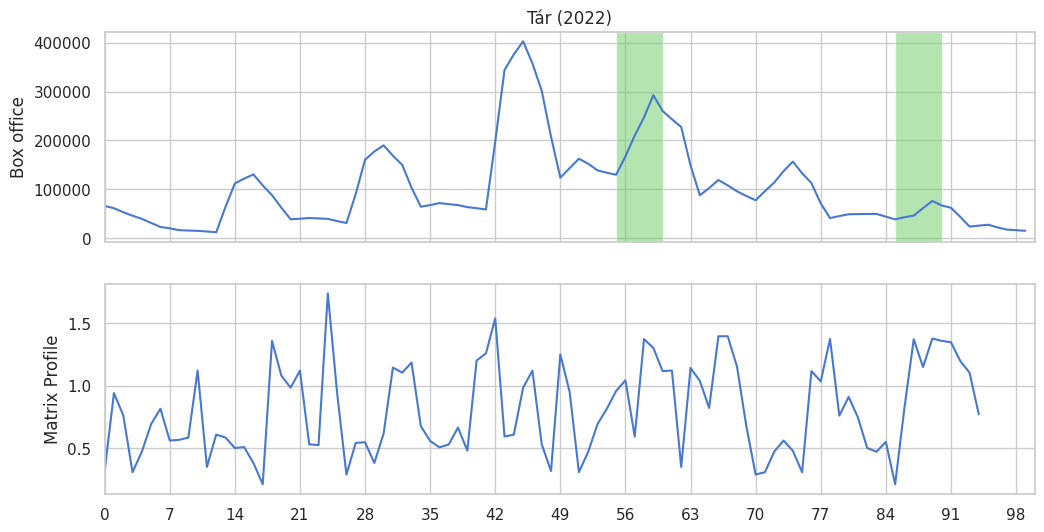

In [20]:
for movie_id in density_based_medoids:
    axs = plot_ts_and_matrix_profile(movie_id)
    plot_motifs(movie_id, axs)
    plot_discords(movie_id, axs)
    plt.show()

### Structural features-based clustering medoids

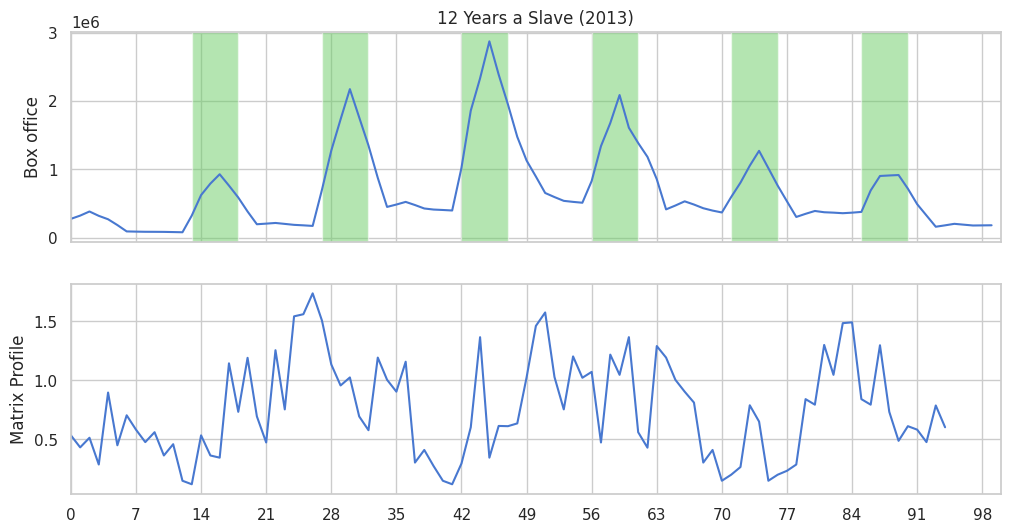

/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/stumpy/motifs.py:380: UserWarning: No motifs were found. You may consider increasing the `cutoff` (e.g., cutoff=0.35884723446639477) and/or increasing the `max_distance `(e.g., max_distance=np.inf).
  warnings.warn(msg)


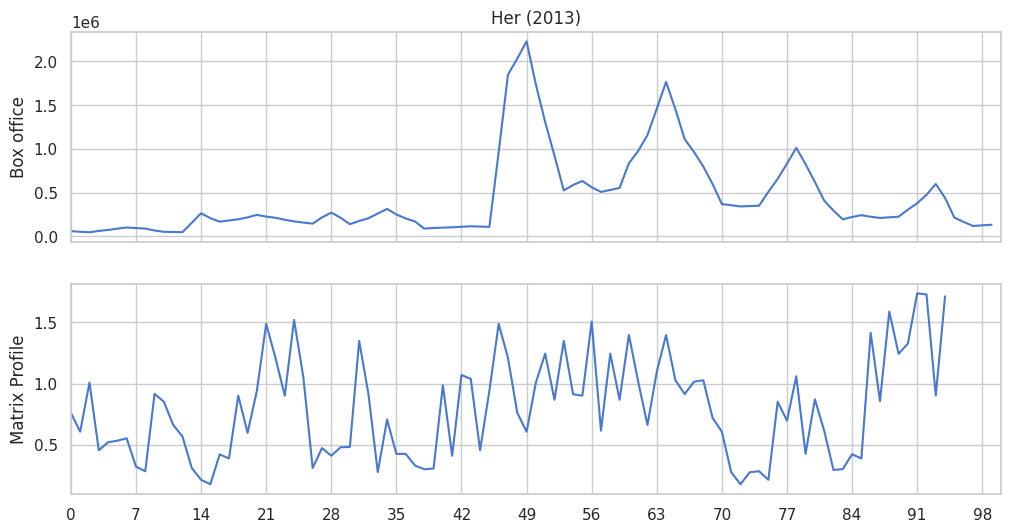

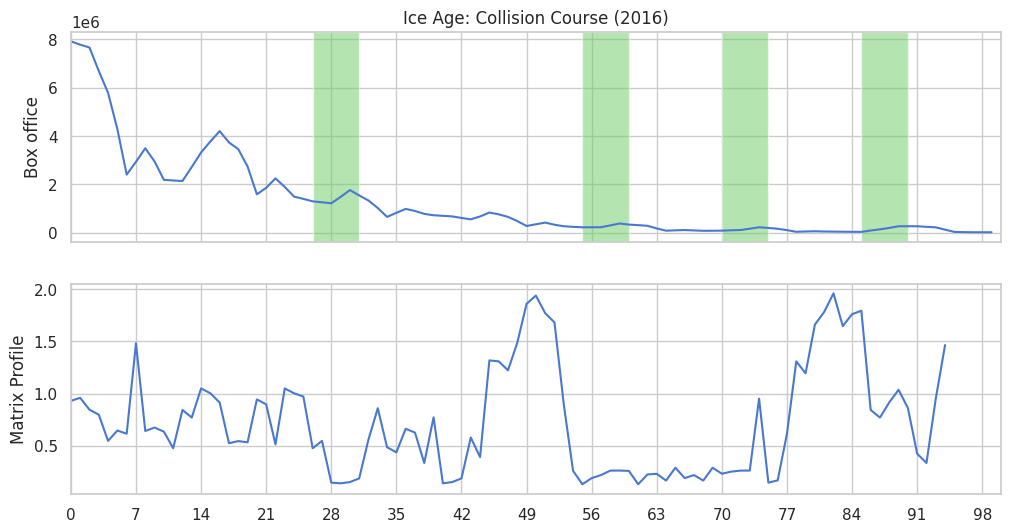

/home/fab/Documents/education/data_mining/dm2_project/.venv/lib/python3.12/site-packages/stumpy/motifs.py:380: UserWarning: No motifs were found. You may consider increasing the `cutoff` (e.g., cutoff=0.6206456343229793) and/or increasing the `max_distance `(e.g., max_distance=np.inf).
  warnings.warn(msg)


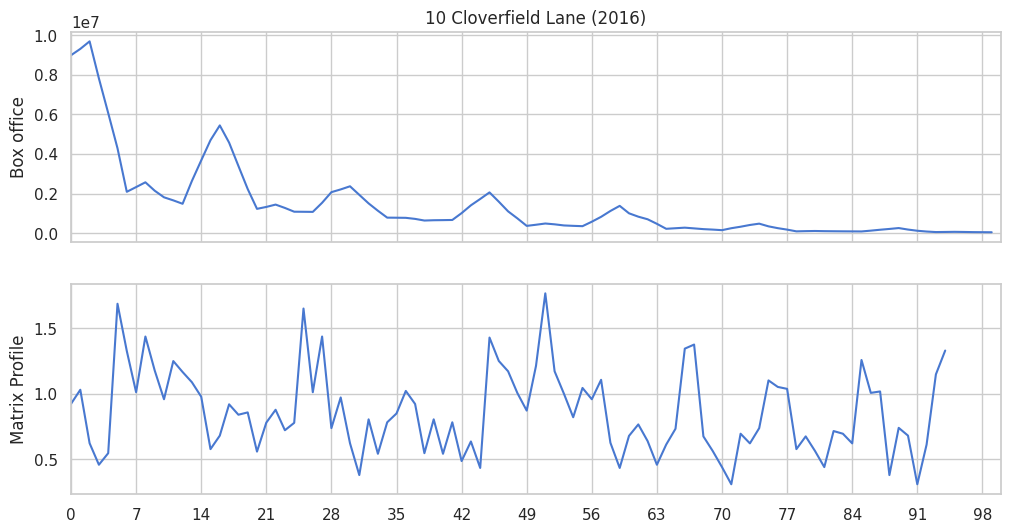

In [21]:
for movie_id in structure_medoids:
    axs = plot_ts_and_matrix_profile(movie_id)
    plot_motifs(movie_id, axs)
    plot_discords(movie_id, axs)
    plt.show()

## Search for discords in the entire dataset

In [22]:
%%time
ts_with_discords = []

for ts in mp.index:
    matrix_profile = mp.loc[ts].values
    ts_discords = get_discords(matrix_profile)
    if ts_discords:
        ts_with_discords.append((ts, ts_discords))



CPU times: user 127 ms, sys: 4.03 ms, total: 131 ms
Wall time: 127 ms


In [23]:
print(len(ts_with_discords))
anomalies = train.loc[[idx for idx, _ in ts_with_discords]].iloc[:,:13]
anomalies.sort_values('numVotes', ascending=False).head()

89


,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,awards,nominations,rating,genre,rating_category,totalGrossIncome,awardsRatio
id,,,,,,,,,,,,,
tt0993846,The Wolf of Wall Street,2013,180,1711865,['US'],True,38.0,180.0,8.2,"['Biography', 'Comedy', 'Crime']",High,2.150253e+08,0.174312
tt1392190,Mad Max: Fury Road,2015,120,1177539,"['AU', 'US']",True,245.0,234.0,8.1,"['Action', 'Adventure', 'Sci-Fi']",High,2.897738e+08,0.511482
tt2488496,Star Wars: Episode VII - The Force Awakens,2015,138,1007831,"['US', 'GB']",True,64.0,140.0,7.8,"['Action', 'Adventure', 'Sci-Fi']",High,1.763034e+09,0.313725
tt2395427,Avengers: Age of Ultron,2015,141,971638,['US'],True,8.0,52.0,7.3,"['Action', 'Adventure', 'Sci-Fi']",High,8.590129e+08,0.133333
tt1825683,Black Panther,2018,134,885839,['US'],NaN,NaN,NaN,7.3,"['Action', 'Adventure', 'Sci-Fi']",High,1.290769e+09,0.000000


In [24]:
# Only if you want to visualize 89 time series
# for movie_id in anomalies.index:
#     axs = plot_ts_and_matrix_profile(movie_id)
#     plot_discords(movie_id, axs)

With ours more stringent definition of discords, we found out that only 89 records in the entire dataset displayed any discords.

/tmp/ipykernel_47264/313704678.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['hasAnomalies'].fillna(False, inplace=True)
/tmp/ipykernel_47264/313704678.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train['hasAnomalies'].fillna(False, inplace=True)


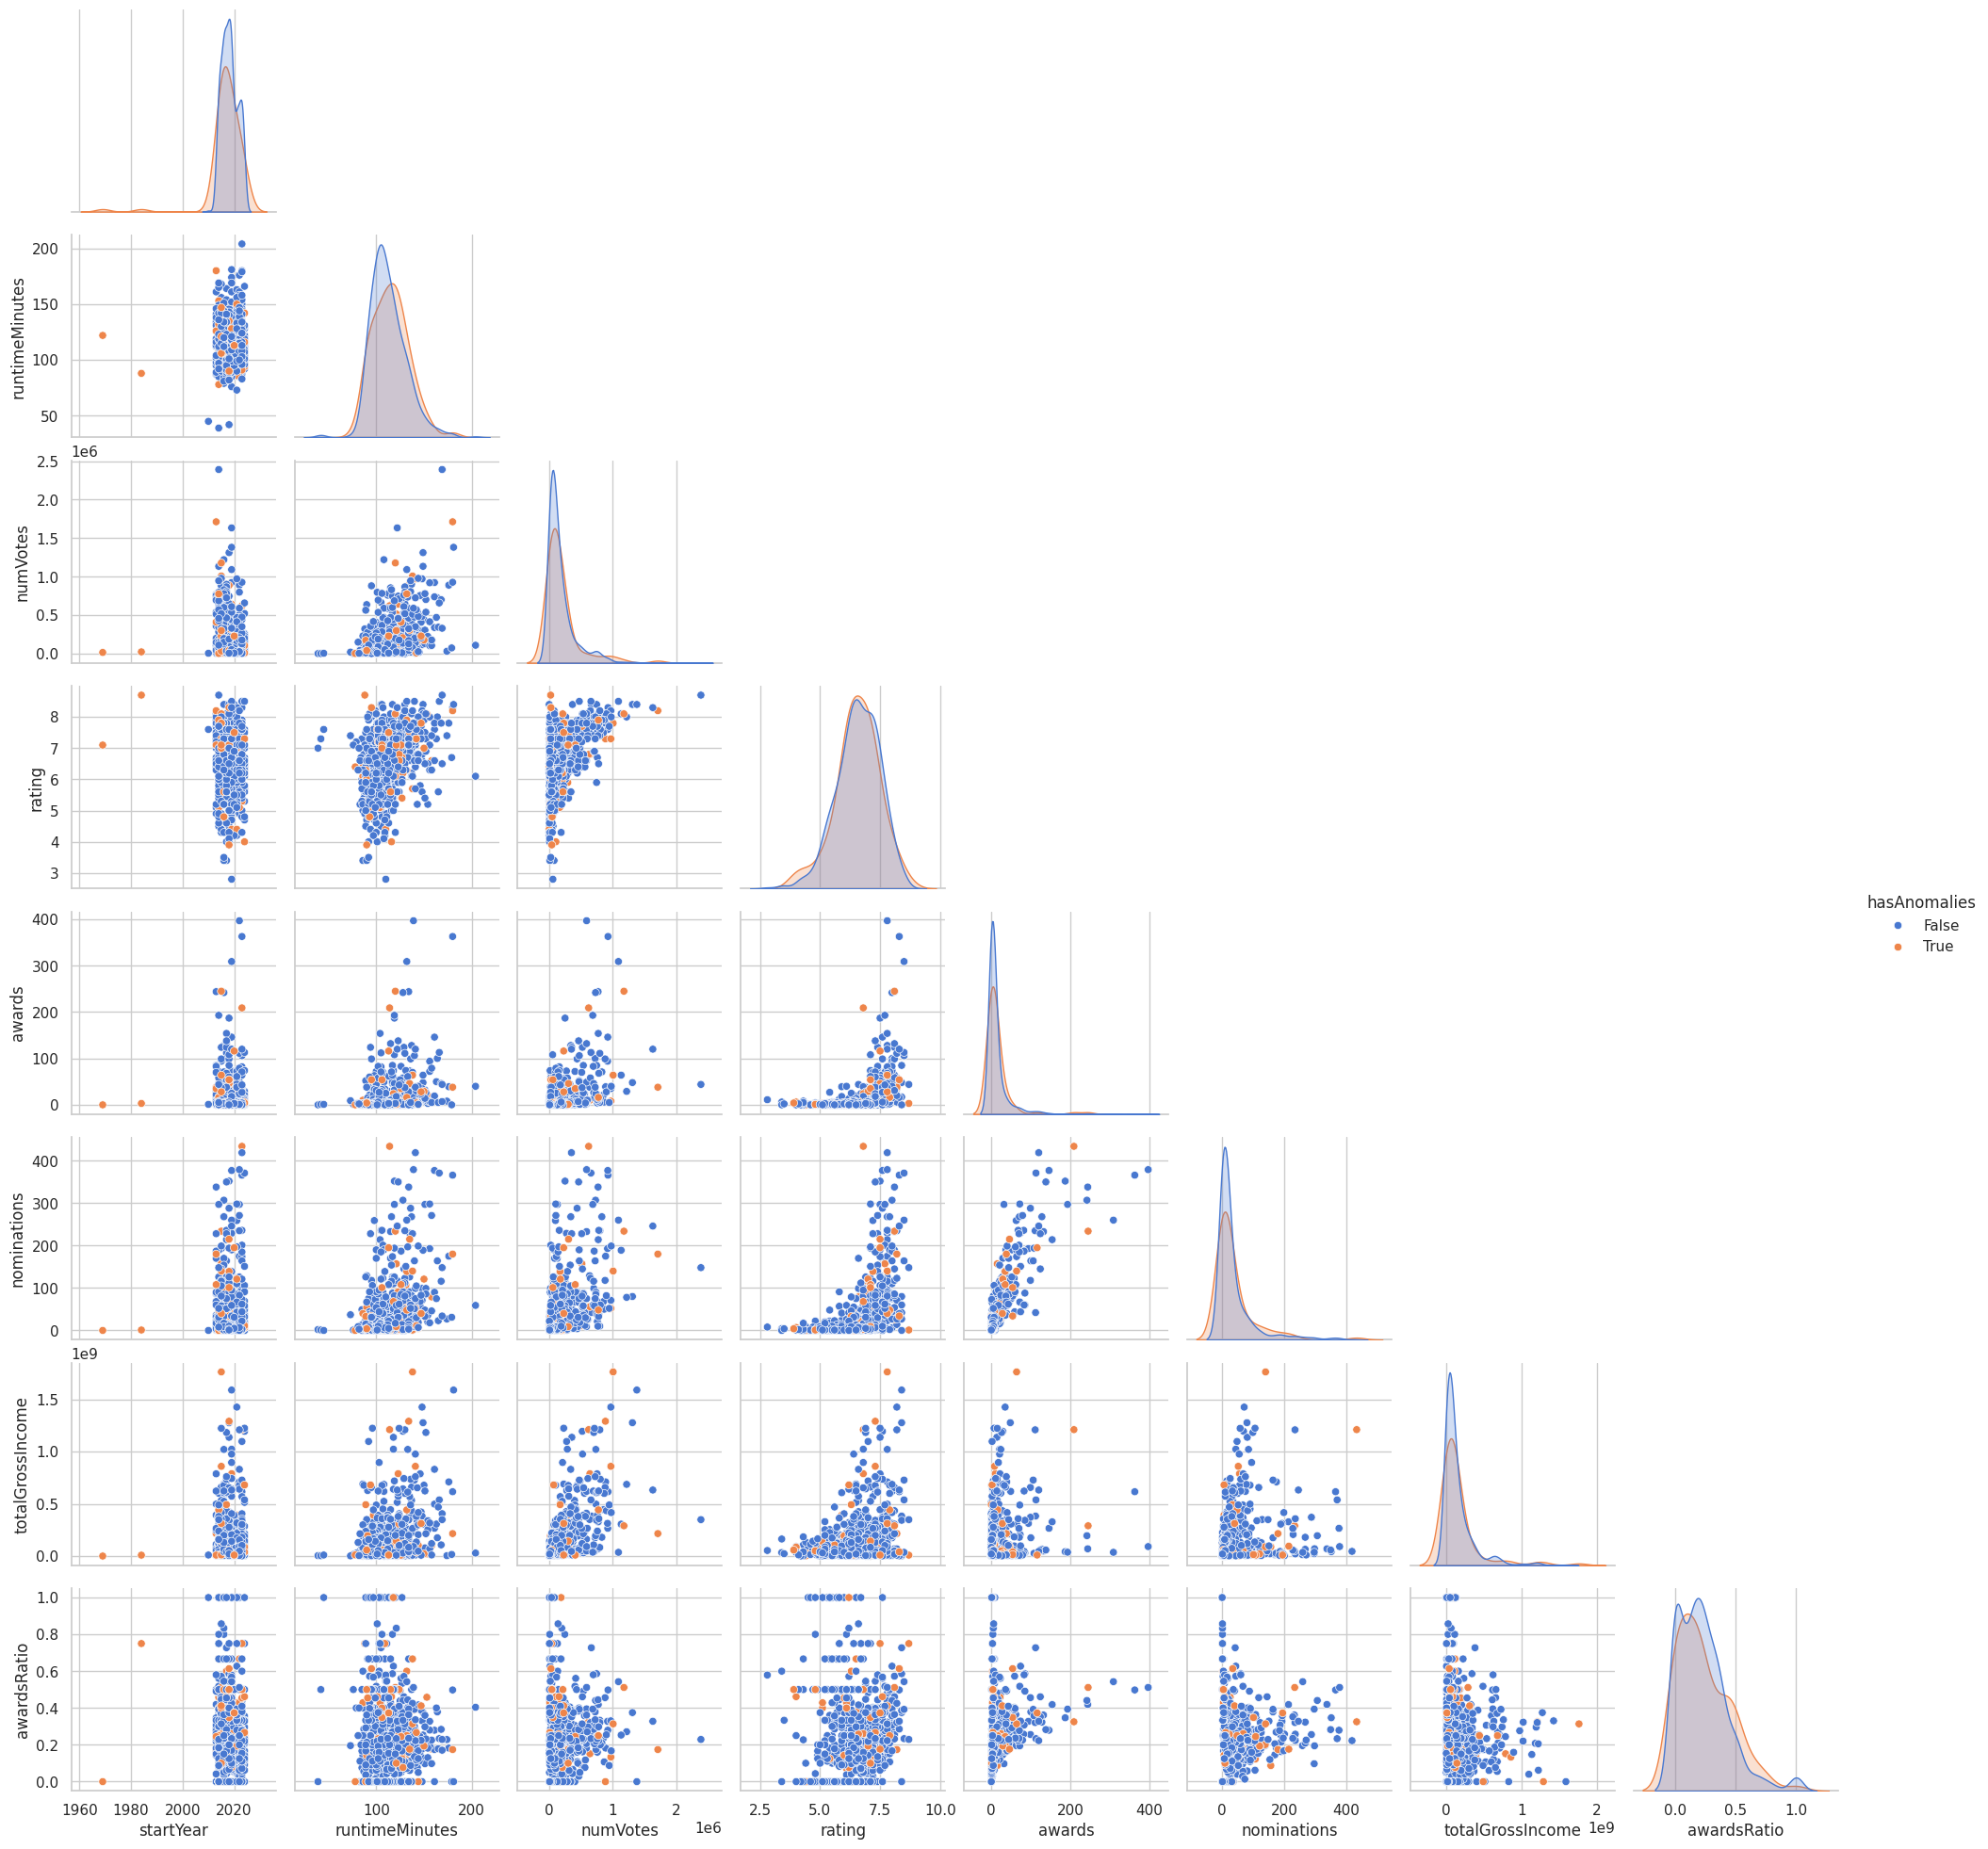

In [25]:
train.loc[anomalies.index, 'hasAnomalies'] = True
train['hasAnomalies'].fillna(False, inplace=True)

num_feats = ['startYear', 'runtimeMinutes', 'numVotes', 'rating', 'awards', 'nominations', 'totalGrossIncome', 'awardsRatio']
sns.pairplot(train, vars=num_feats, corner=True, hue='hasAnomalies', diag_kws=dict(common_norm=False))

Nothing much to see here, except that the two records that we noticed were anomalous with respect to startYear, have indeed anomalies.
This may warn us that our analysis isn't really generalizable to longer box office trends out of the specific time span we are seeing here, as it is predicated on societary trends that may have less staying power that we may think.

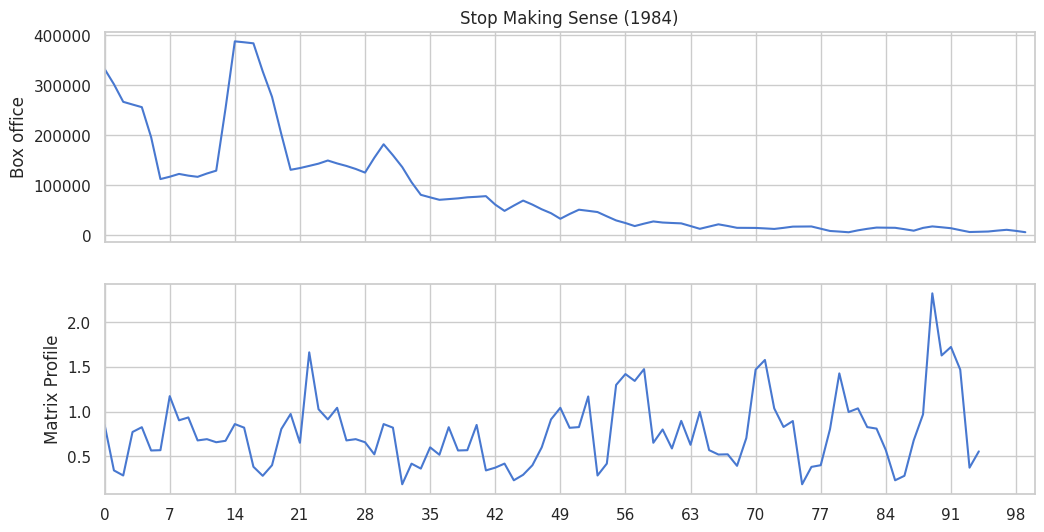

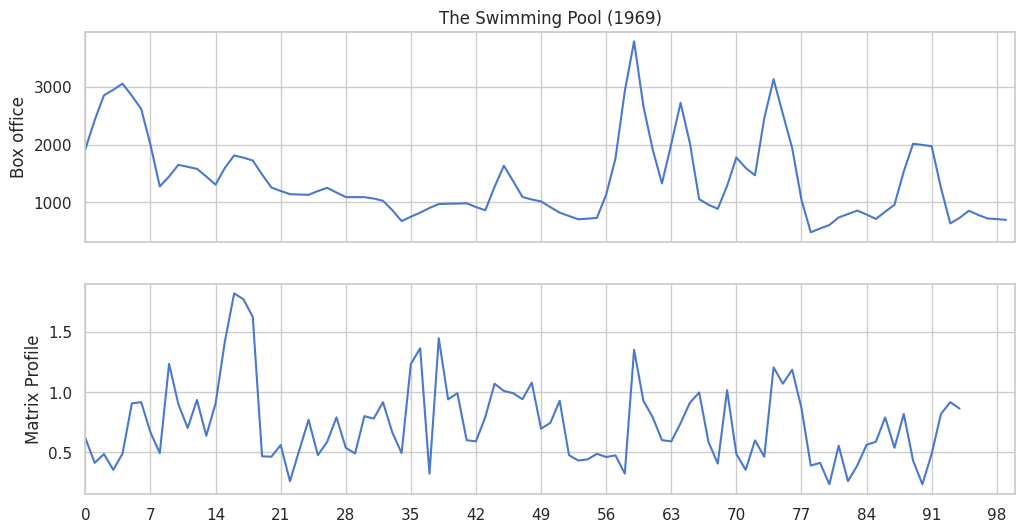

In [26]:
for movie_idx in list(train[train['startYear'] < 2010].index):
    axs = plot_ts_and_matrix_profile(movie_idx)
    plot_discords(movie_id, axs)

## Conserved patterns

In [27]:
mad_max = train_X.loc[shape_medoids[1], 'value']
twelve_years = train_X.loc[shape_medoids[2], 'value']

mad_max_mp = stumpy.stump(mad_max,
                          m,
                          twelve_years,
                          ignore_trivial=False)

In [28]:
def find_conserved_patterns(ts1, ts2):
    mp = stumpy.stump(ts1, m, ts2, ignore_trivial=False)
    ts1_idx = mp.P_.argmin()
    ts2_idx = mp.I_[ts1_idx]
    dist = mp.P_[ts1_idx]
    return ts1_idx, ts2_idx, dist

In this case the best matching pattern is symmetric

In [29]:
print(find_conserved_patterns(mad_max, twelve_years))
print(find_conserved_patterns(twelve_years, mad_max))

(np.int64(40), np.int64(25), np.float64(0.058673588708726424))
(np.int64(25), np.int64(40), np.float64(0.058673588708737776))


In [30]:
mad_max_motif_index, twelve_years_motif_index, _ = find_conserved_patterns(mad_max, twelve_years)

print(f"The motif is located at index {mad_max_motif_index} of 'Mad Max: Fury Road'")
print(f"The motif is located at index {twelve_years_motif_index} of 'Twelve Years a Slave")

The motif is located at index 40 of 'Mad Max: Fury Road'
The motif is located at index 25 of 'Twelve Years a Slave


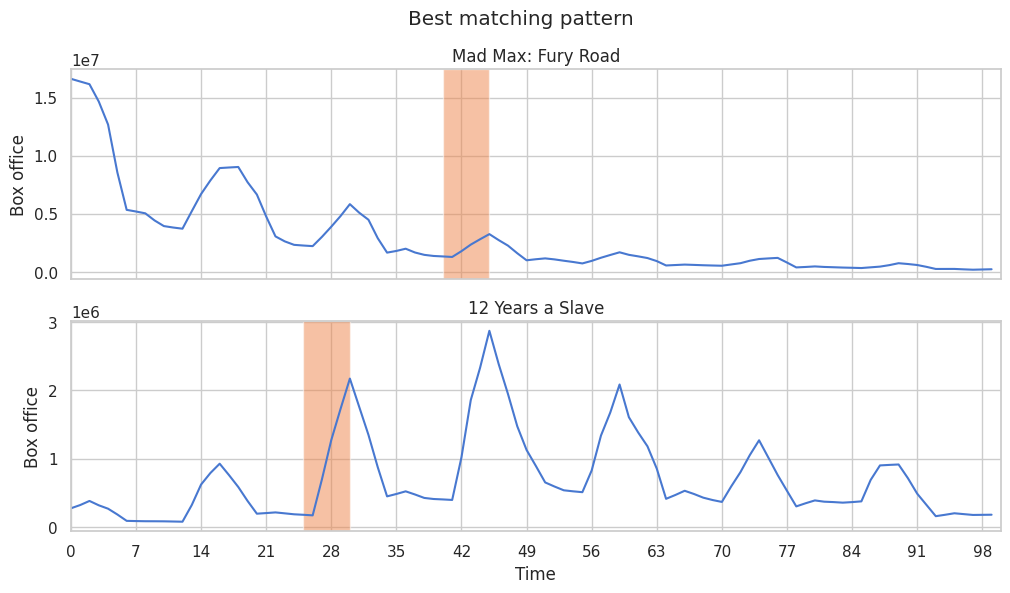

In [31]:
fig, axs = plt.subplots(2, sharex=True)
plt.suptitle('Best matching pattern')

axs[0].set_title('Mad Max: Fury Road')
axs[1].set_title('12 Years a Slave')

axs[1].set_xlabel('Time')
axs[0].set_ylabel('Box office')
axs[1].set_ylabel('Box office')

axs[0].plot(mad_max)
axs[1].plot(twelve_years)
plt.xticks(np.arange(0, 100, 7))
plt.xlim((0, 100))



lower, upper = axs[0].get_ylim()
height = upper - lower
rect = Rectangle((mad_max_motif_index, lower), m-1, height, facecolor='C1', alpha=.5)
axs[0].add_patch(rect)


lower, upper = axs[1].get_ylim()
height = upper - lower
rect = Rectangle((twelve_years_motif_index, lower), m-1, height, facecolor='C1', alpha=.5)
axs[1].add_patch(rect)

plt.show()

Interestingly, this conserved pattern is also a motif in *Mad Max: Fury Road*.
This may suggest that the seasonal peaks in movies from the two clusters are not so different afer all, and may reflect a general pattern of movie-goers behaviour.

In [32]:
mad_max_z_norm_motif = core.z_norm(mad_max.iloc[mad_max_motif_index:mad_max_motif_index+m].values)
twelve_years_z_norm_motif = core.z_norm(twelve_years.iloc[twelve_years_motif_index:twelve_years_motif_index+m].values)

Text(0, 0.5, 'Normalized Box Office')

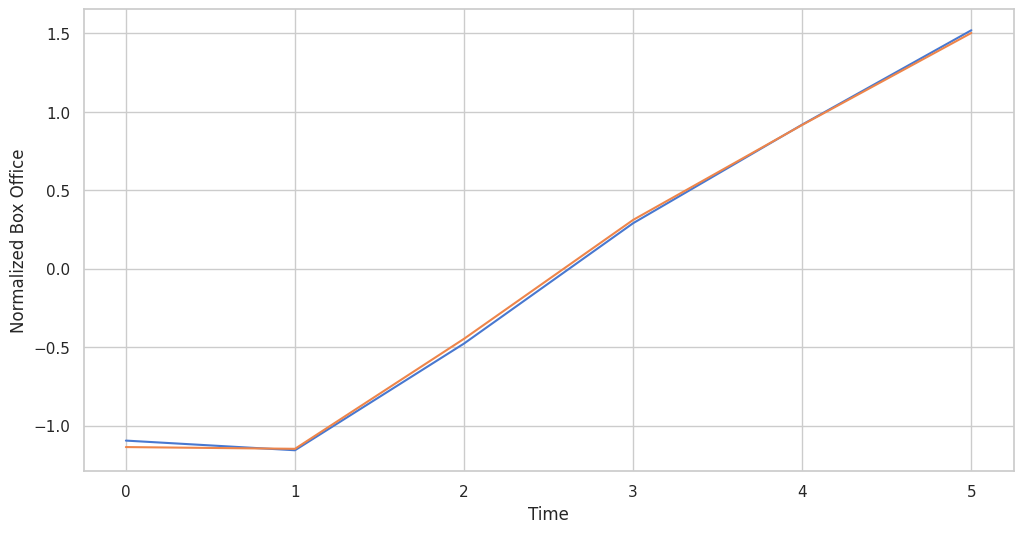

In [33]:
plt.plot(mad_max_z_norm_motif, label='Mad Max: Fury Road')
plt.plot(twelve_years_z_norm_motif, label='Twelve Years a Slave')

plt.xlabel('Time')
plt.ylabel('Normalized Box Office')

## Chains

In [34]:
ts = twelve_years

ts_mp = stumpy.stump(ts, m=m)
all_chain_set, unanchored_chain = stumpy.allc(ts_mp.left_I_, ts_mp.right_I_)

palette = plt.cm.plasma(np.linspace(0, .7, len(unanchored_chain)))

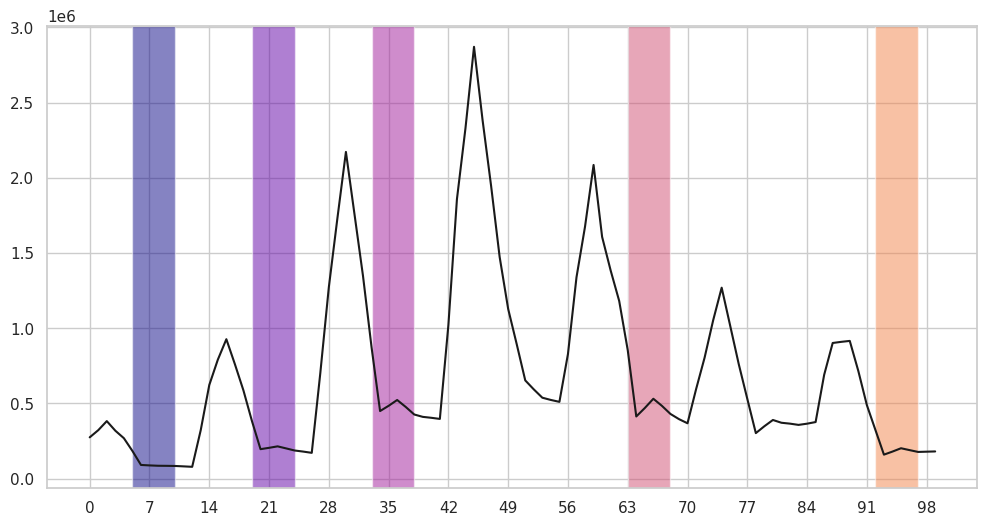

In [35]:
fig, axs = plt.subplots()

axs.plot(ts, color='k')
lower, upper = axs.get_ylim()
height = upper - lower

for i in range(unanchored_chain.shape[0]):
    start = unanchored_chain[i]
    y = ts.iloc[start:start+m]
    x = y.index.values
    rect = Rectangle((start, lower), m-1, height, facecolor=palette[i], alpha=.5)
    axs.add_patch(rect)
plt.xticks(np.arange(0, 100, 7))
plt.show()


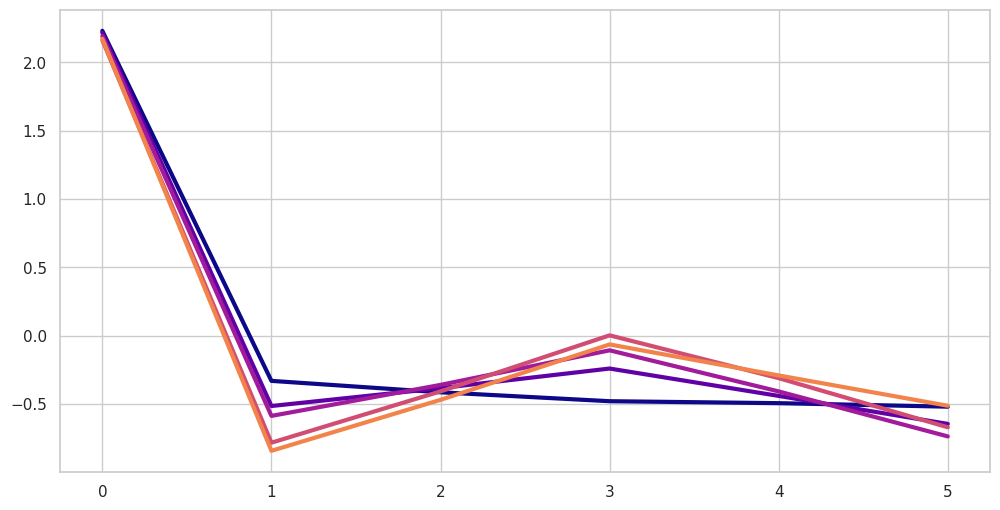

In [36]:
fig, axs = plt.subplots()
for i in range(unanchored_chain.shape[0]):
    start = unanchored_chain[i]
    seq = core.z_norm(ts.iloc[start:start+m].values)
    axs.plot(seq, linewidth=3, color=palette[i])

Looks like the line coming down becomes less steep, while the central minor peak at the center of the motif is getting more pronounced.

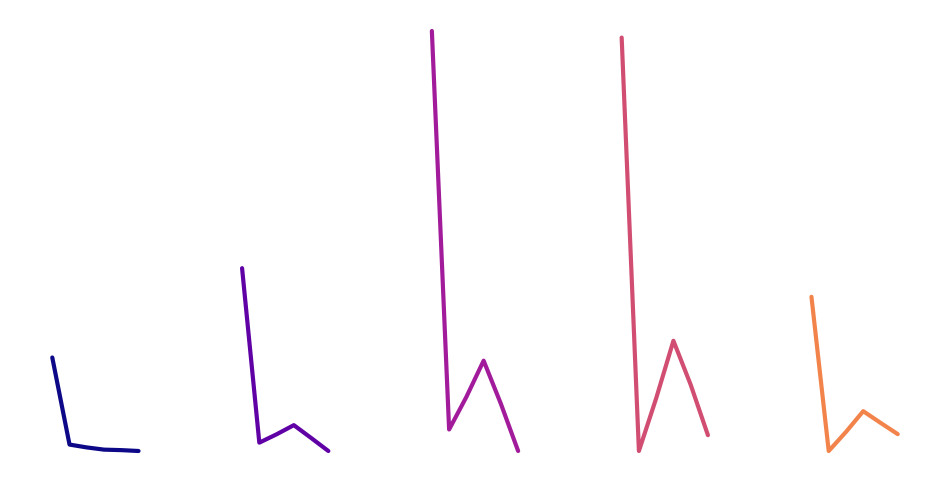

In [37]:
plt.axis('off')
for i in range(unanchored_chain.shape[0]):
    data = ts.iloc[unanchored_chain[i]:unanchored_chain[i]+m].reset_index()
    x = data.iloc[:, 0]
    y = data.iloc[:, 1]
    plt.plot(x-x.min()+(m+5)*i, y-y.min(), linewidth=3, color=palette[i])
plt.show()

## Consensus motif

The general idea is to find a conserved motif that is common across all time series within the set. This is not so loosely based on [this stumpy documentation tutorial](https://stumpy.readthedocs.io/en/latest/Tutorial_Consensus_Motif.html).

In this case we extract a longer motif, representing the trend of the box-office on a four weeks time span.

In [38]:
m = 28

In [39]:
Ts = []
for idx in train.index:
    Ts.append(train_X.loc[idx, 'value'].values)
len(Ts)

850

In [40]:
%%time
radius, Ts_idx, subseq_idx = stumpy.ostinato(Ts, m)

CPU times: user 2min 45s, sys: 178 ms, total: 2min 45s
Wall time: 1min 33s


In [41]:
print(f'Found Best Radius {radius:.2f} in time series {train.index[Ts_idx]} starting at subsequence index {subseq_idx}')

Found Best Radius 3.82 in time series tt11152168 starting at subsequence index 28


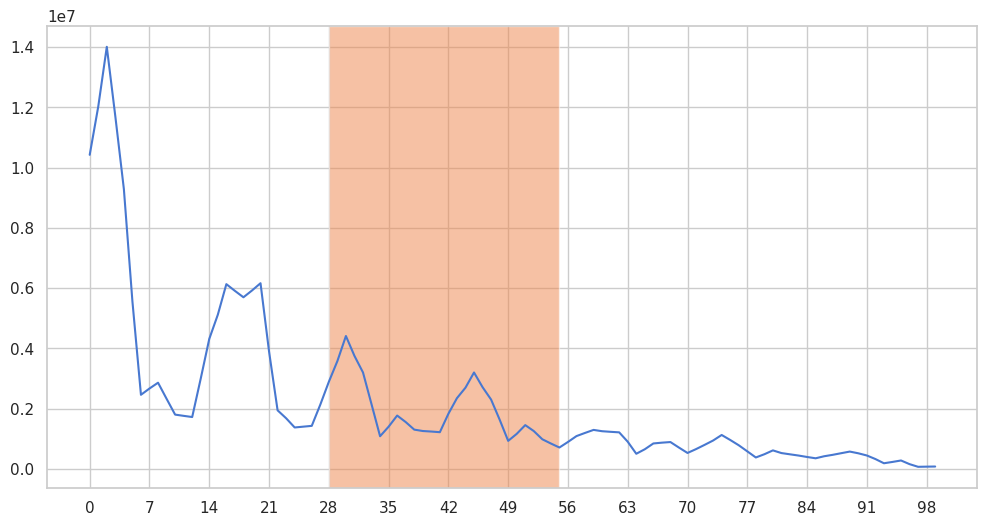

In [42]:
fig, axs = plt.subplots()
axs.plot(Ts[Ts_idx])

lower, upper = axs.get_ylim()
height = upper - lower
rect = Rectangle((subseq_idx, lower), m-1, height, facecolor='C1', alpha=.5)
axs.add_patch(rect)
plt.xticks(np.arange(0, 100, 7))
plt.show()

/tmp/ipykernel_47264/215558603.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


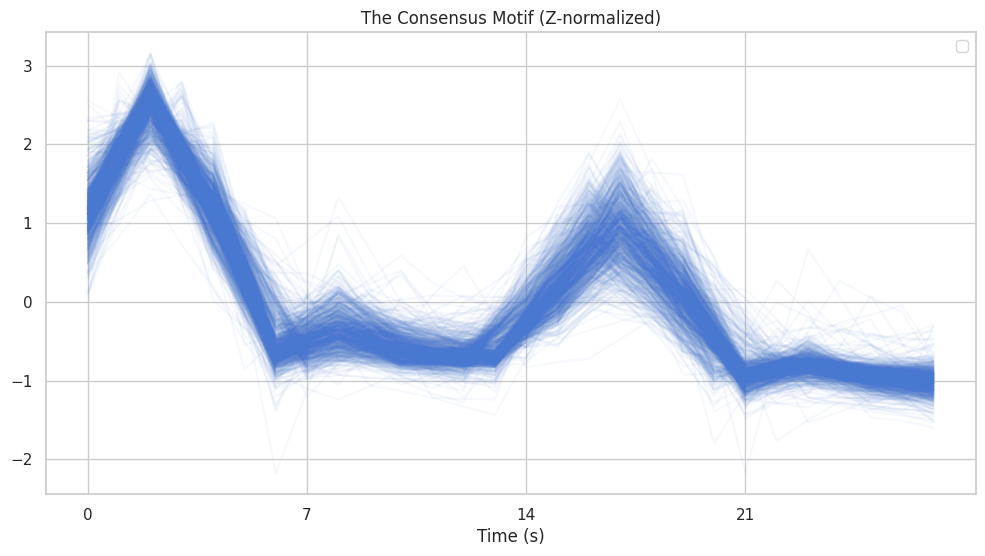

In [43]:
consensus_motif = Ts[Ts_idx][subseq_idx : subseq_idx + m]
nn_idx = []

for i, T in enumerate(Ts):
    nn_idx.append(np.argmin(stumpy.core.mass(consensus_motif, T)))
    plt.plot(stumpy.core.z_norm(T[nn_idx[i] : nn_idx[i]+m]), alpha=0.05, label=None, c='b')

plt.title('The Consensus Motif (Z-normalized)')
plt.xlabel('Time (s)')
plt.legend()
plt.xticks(np.arange(0, 28, 7))
plt.show()

This is well known to us at this point: two major peaks (the second smaller than the first) in two non consecutive weeks and smaller peaks after each major peak.

For most time series we observe only small deviations from this motif: for example a subtle anticipation of the second major peak or a relatively higher minor peak.

## Clustering on consensus motif

In [44]:
stumpy.mass(mad_max, twelve_years).item()

14.632685542861937

Note that this returns the euclidean distance between the two sequences after amplitude scaling, so we do that instead (but we make stumpy do the normalization).

We perform clustering again, but instead of measuring distances between whole timeseries, we use the common consensus motif.

In [45]:
common_subseqs = []
for i, start in enumerate(nn_idx):
    subseq = stumpy.core.z_norm(Ts[i][start:start+m])
    common_subseqs.append(subseq)

In [46]:
train_X_sub = pd.DataFrame(common_subseqs)
train_X_sub.index = train.index
train_X_sub.shape

(850, 28)

### Hierarchical clustering

In [47]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
def get_linkage_matrix(model):
    # Create linkage matrix

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    return linkage_matrix

def plot_dendrogram(model, **kwargs):
    linkage_matrix = get_linkage_matrix(model)
    dendrogram(linkage_matrix, **kwargs)

In [48]:
hier_clust = AgglomerativeClustering(
    n_clusters=None, distance_threshold=0, linkage='ward'
)
hier_clust.fit(train_X_sub)

,n_clusters,None
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,0
,compute_distances,False


In [49]:
threshold = 15

([], [])

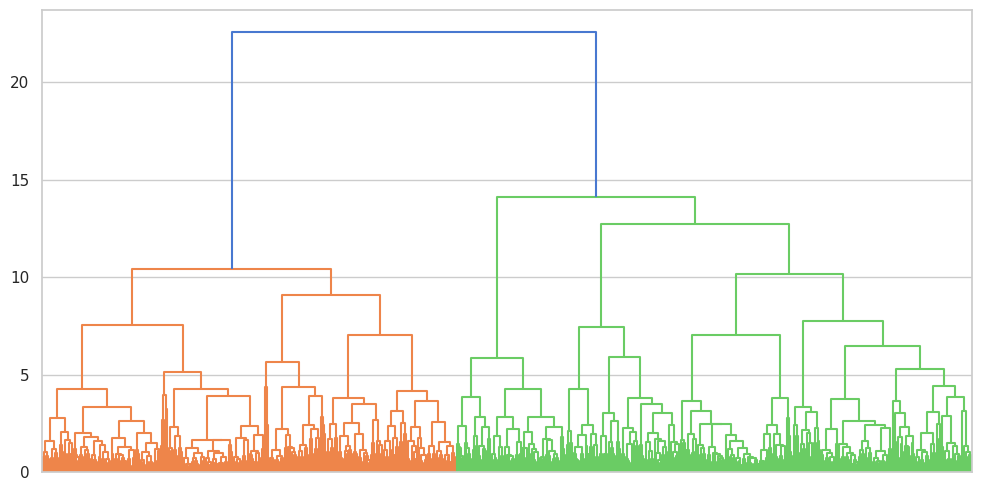

In [50]:
plot_dendrogram(hier_clust, color_threshold=threshold)
plt.xticks([], [])

In [51]:
linkage_matrix = get_linkage_matrix(hier_clust)
labels = fcluster(linkage_matrix, criterion='distance', t=threshold)

In [52]:
np.unique(labels, return_counts=True)

(array([1, 2], dtype=int32), array([378, 472]))

In [53]:
print("Silhouette score:", silhouette_score(train_X_sub, labels=labels))

Silhouette score: 0.1463539622048728


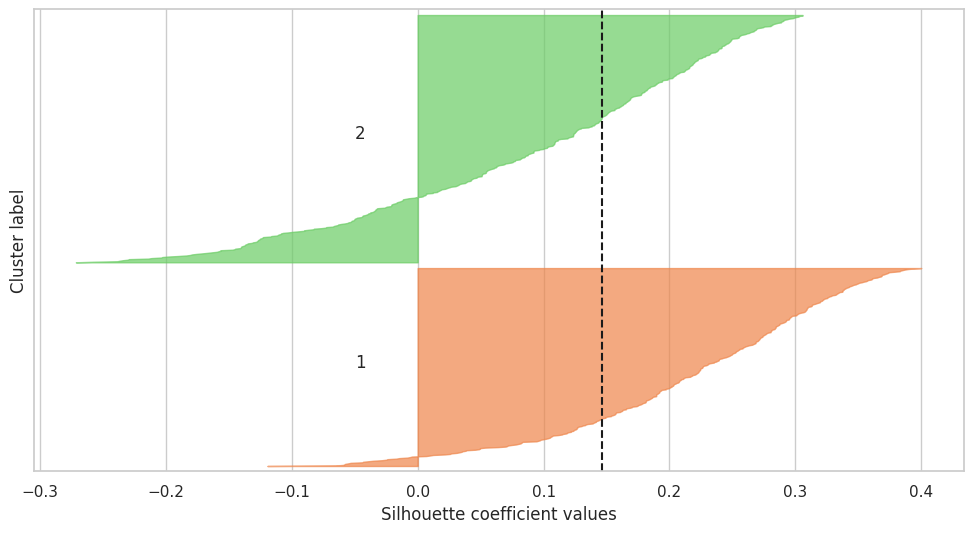

In [54]:
plot_silhouette(train_X_sub, labels)

Not a great silhouette.

### DBSCAN

In [55]:
%%time

optics = OPTICS(metric='euclidean', n_jobs=-1)
optics.fit(train_X_sub)

CPU times: user 16.2 s, sys: 188 ms, total: 16.4 s
Wall time: 2.43 s


,min_samples,5
,max_eps,inf
,metric,'euclidean'
,p,2
,metric_params,None
,cluster_method,'xi'
,eps,None
,xi,0.05
,predecessor_correction,True
,min_cluster_size,None
,algorithm,'auto'


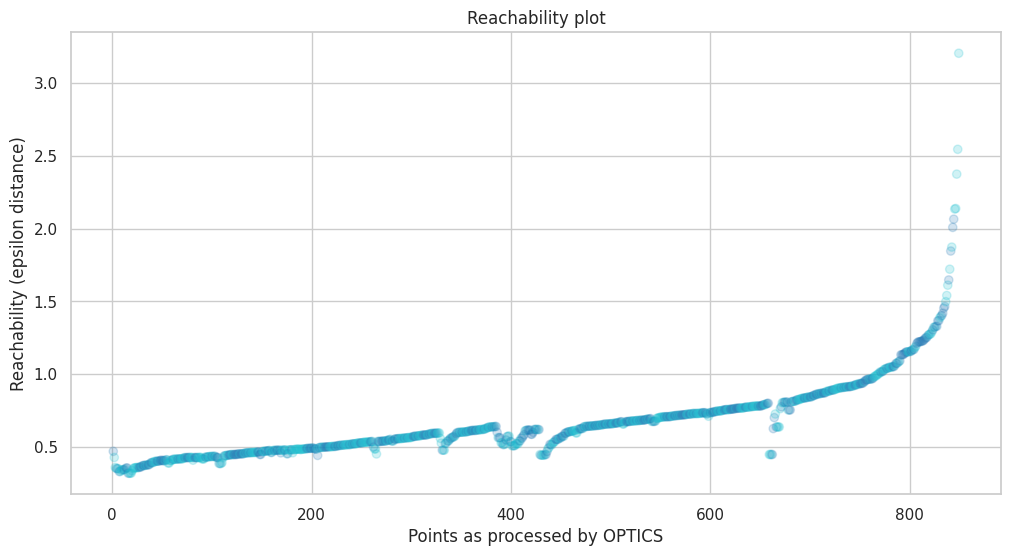

In [56]:
space = np.arange(len(train_X_sub))
reachability = optics.reachability_[optics.ordering_]
plt.title("Reachability plot")
plt.ylabel("Reachability (epsilon distance)")
plt.xlabel("Points as processed by OPTICS")
plt.scatter(space, reachability, alpha=.2, c=labels, cmap='tab10')

In [57]:
optics_labels = cluster_optics_dbscan(
    reachability=optics.reachability_,
    core_distances=optics.core_distances_,
    ordering=optics.ordering_,
    eps=1
)

np.unique(optics_labels, return_counts=True)

(array([-1,  0]), array([ 82, 768]))

Nothing is great here. Maybe we can see if outliers are somewhat different from inliers.

In [58]:
sub_plot = train_X_sub.reset_index().melt(id_vars='id', var_name='time')
sub_plot = sub_plot.set_index(['id', 'time'])

In [59]:
train['hier'] = pd.Categorical(labels)
train['outlier'] = optics_labels == -1
train['outlier'].fillna(False, inplace=True)
sub_plot['hier'] = sub_plot.index.get_level_values(0).map(train['hier'])
sub_plot['outlier'] = sub_plot.index.get_level_values(0).map(train['outlier'])

/tmp/ipykernel_47264/1180825391.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['outlier'].fillna(False, inplace=True)


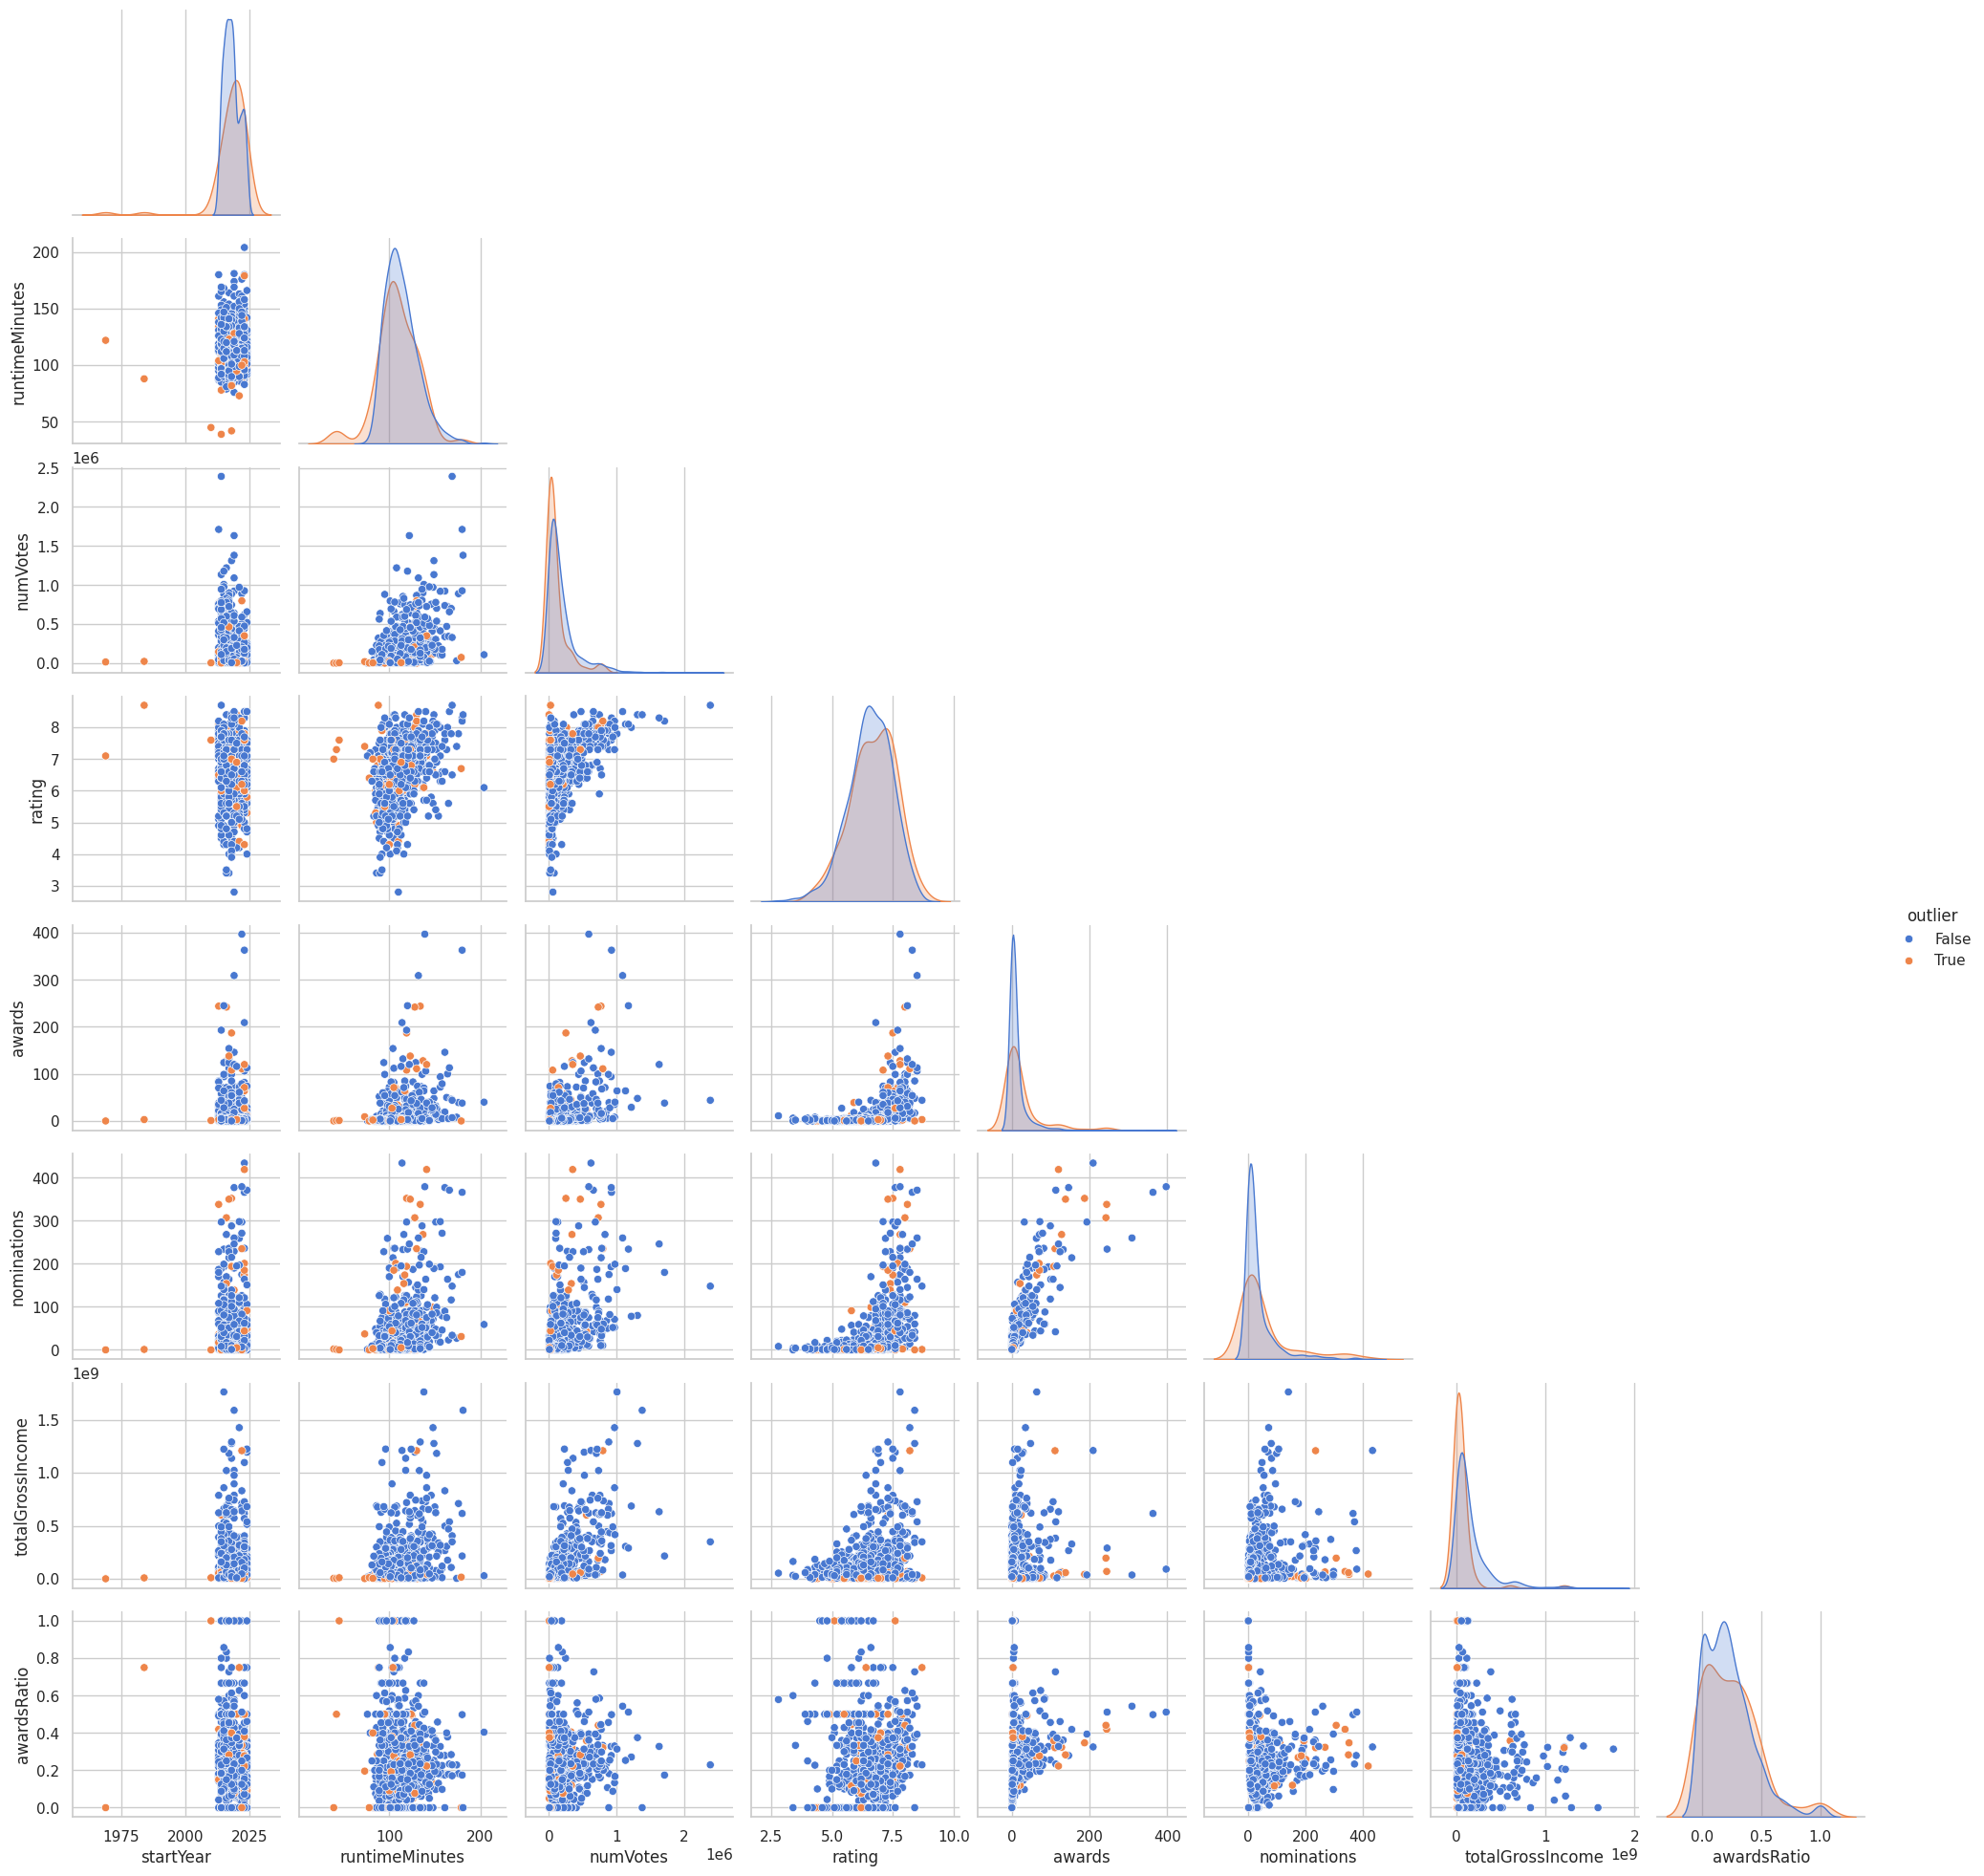

In [60]:
sns.pairplot(train, vars=num_feats, corner=True, hue='outlier', diag_kws=dict(common_norm=False))


Both our `startYear` and `runtimeMinutes` outliers are classified as noise by OPTICS.

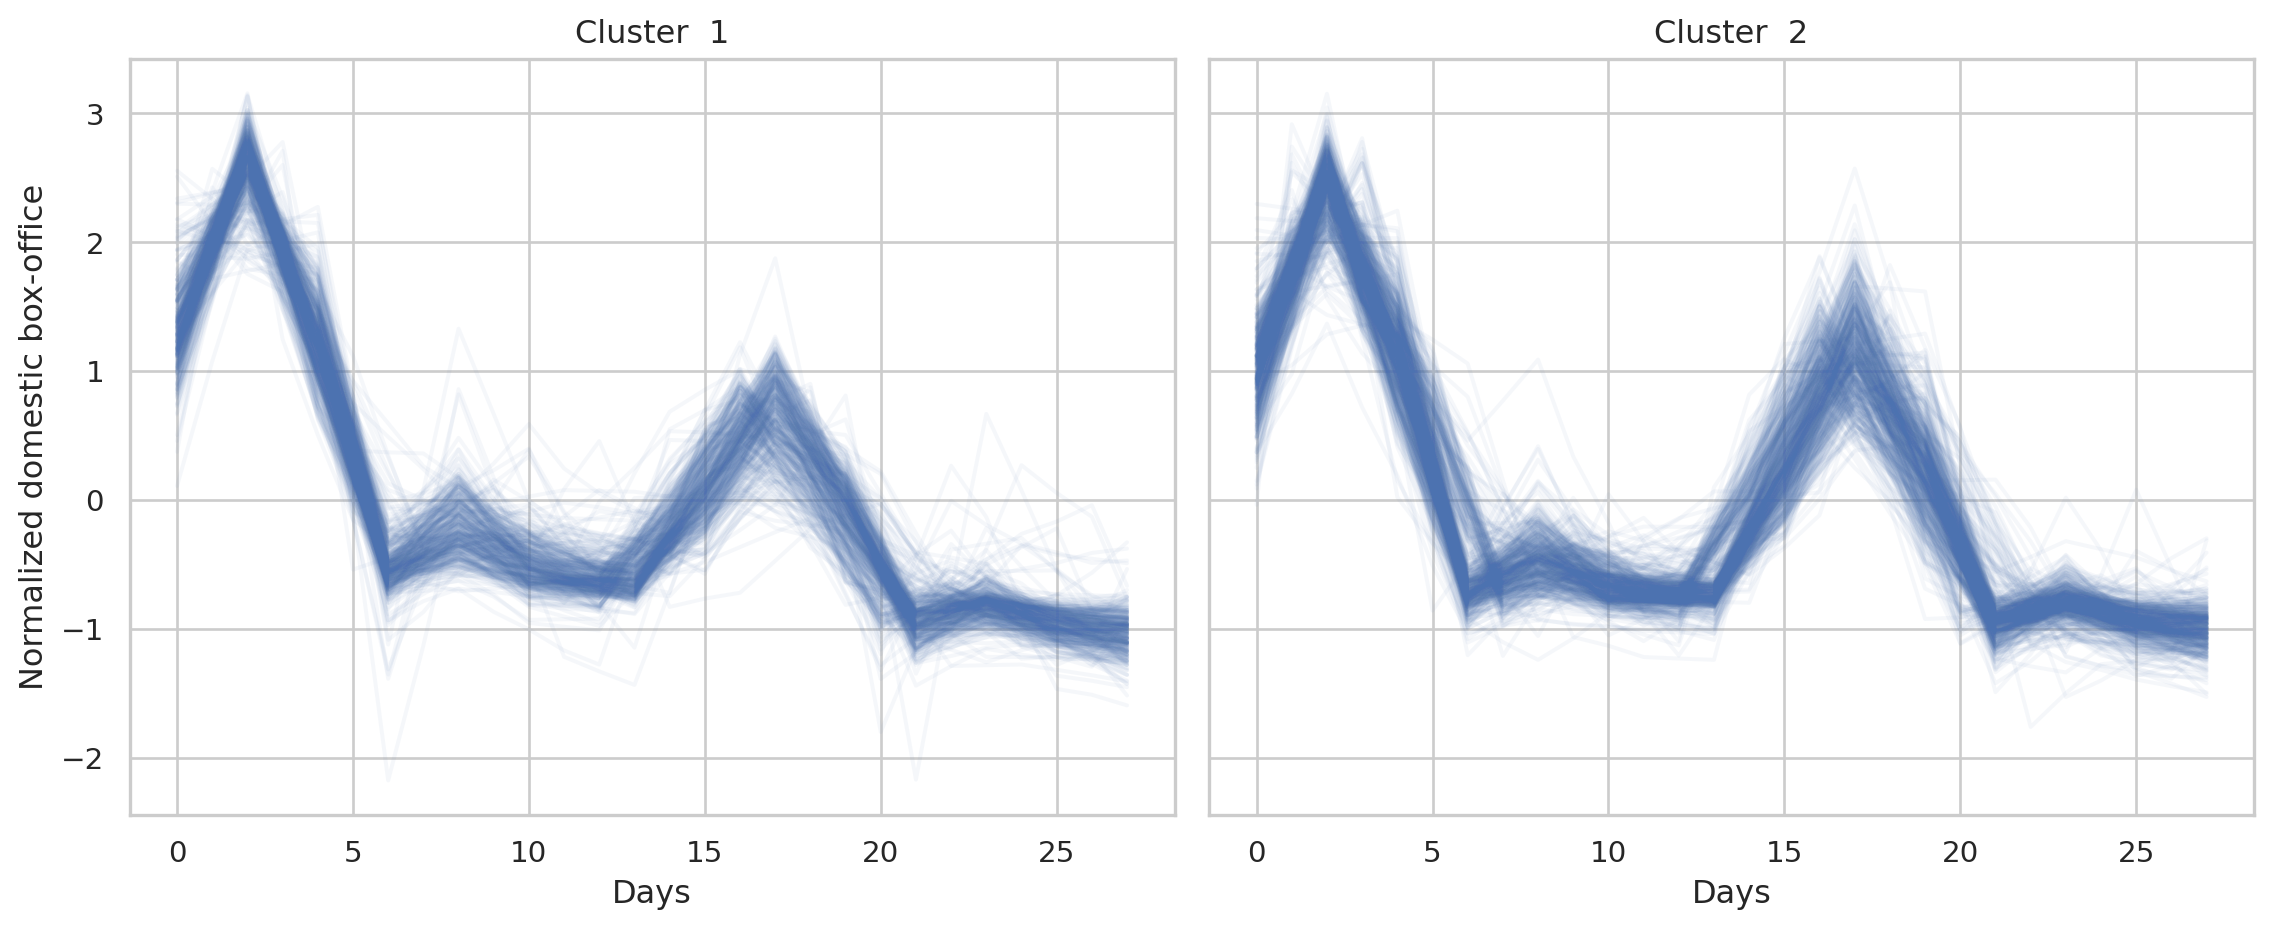

In [61]:
(
    so.Plot(sub_plot, x='time', y='value')
    .facet(col='hier')
    .add(so.Lines(alpha=.05), group='id', legend=False)
    .label(x='Days', y='Normalized domestic box-office', col="Cluster ")
    .layout(size=(12, 5))
)

Second major peek is on average higher for cluster 2 records.

In [62]:
scaler = TabularToSeriesAdaptor(StandardScaler())
complete_plot = scaler.fit_transform(train_X)
complete_plot['outlier'] = complete_plot.index.get_level_values(0).map(train['outlier'])
complete_plot['hier'] = complete_plot.index.get_level_values(0).map(train['hier'])

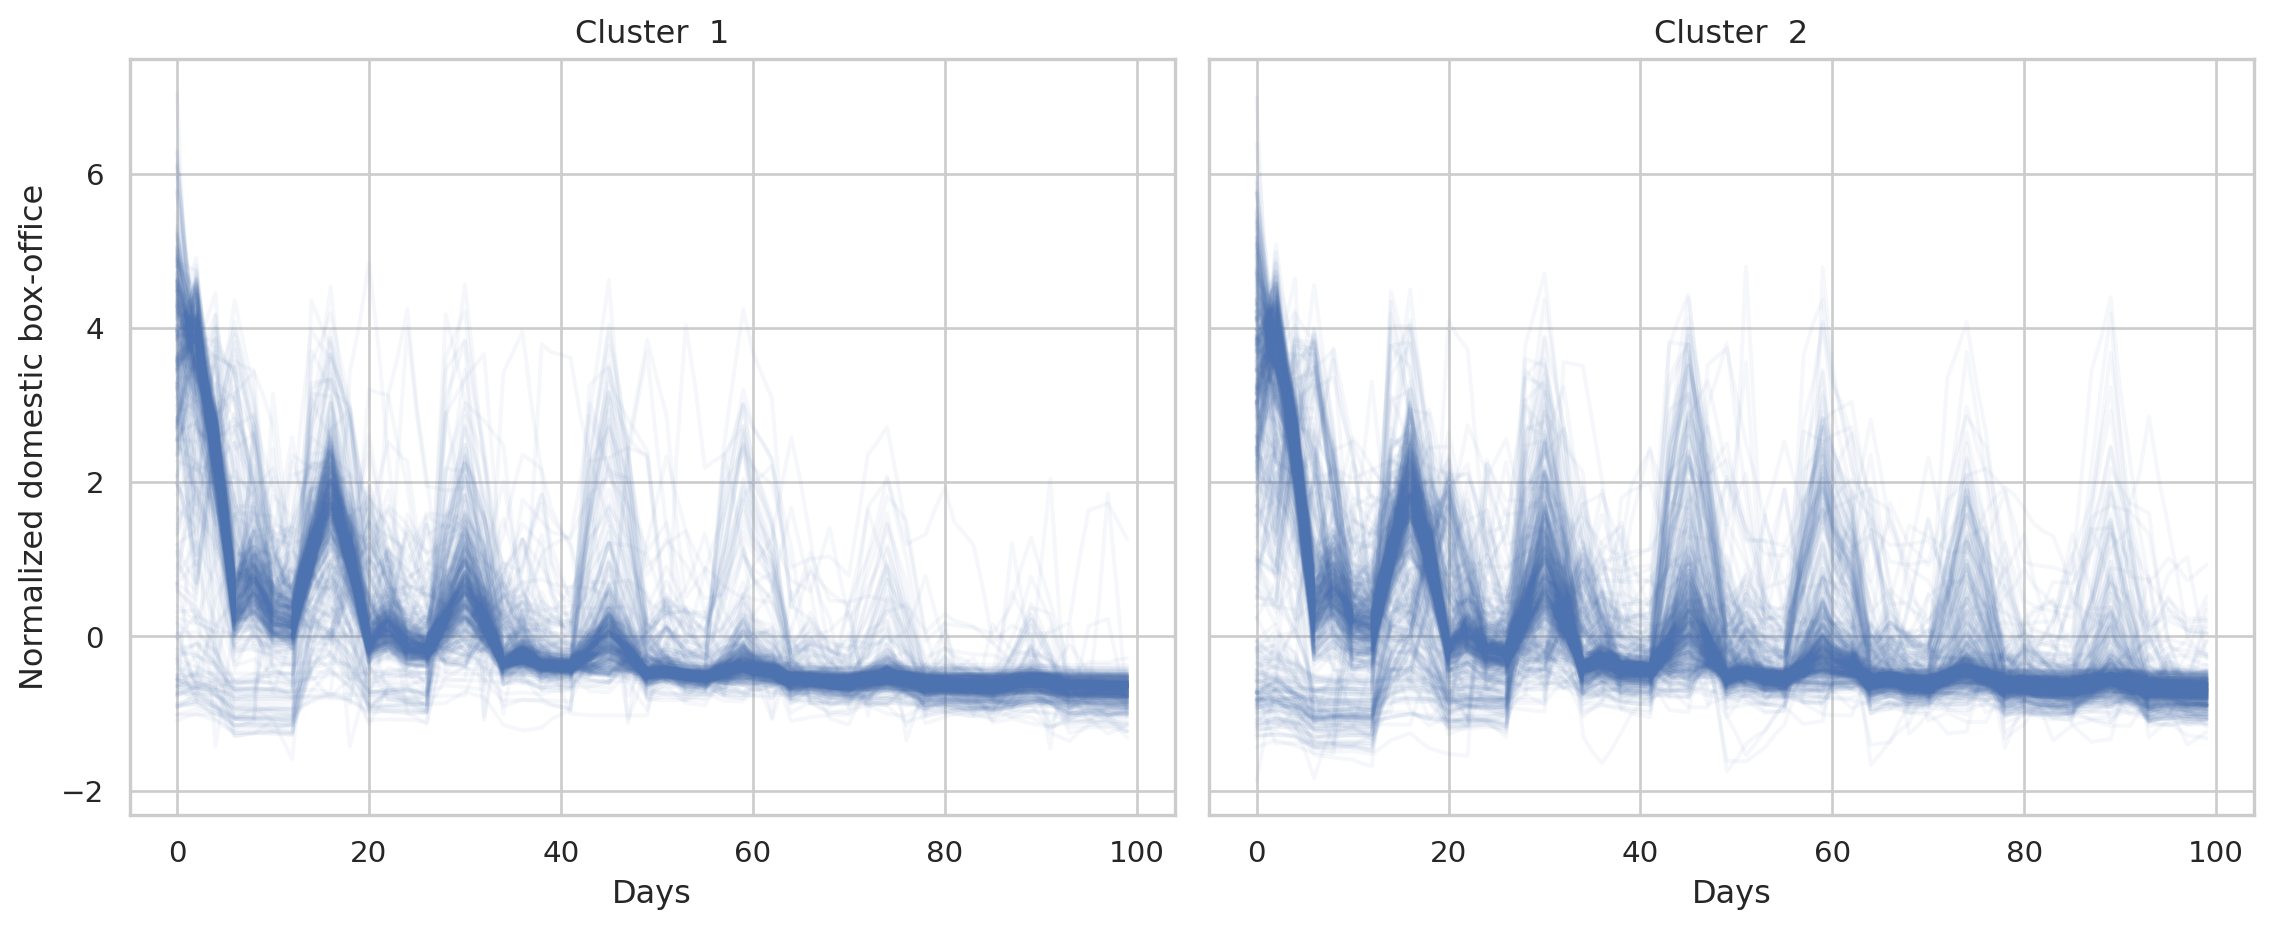

In [63]:
(
    so.Plot(complete_plot, x='time', y='value')
    .facet(col='hier', wrap=2)
    .add(so.Lines(alpha=.05), group='id', legend=False)
    .label(x='Days', y='Normalized domestic box-office', col="Cluster ")
    .layout(size=(12, 5))
)

Clustering failed to yield any results comparable with those obtained by shape based clustering. While some time series conserve the the motif consensus with less fidelity (or arguably nothing at all), it wasn't possible to detect an interesting pattern in the variation of the motif.

This probably makes sense considering the nature of our data: while the shape of the entire timeseries has enable us the find groups of movies with different patterns (especially with respect to the position of the highest peak and the general trend of the time series), this conserved motif is probably registering a common pattern in movie-goers which is largely independent from the characteristics of the specific movie.

<Axes: ylabel='Count'>

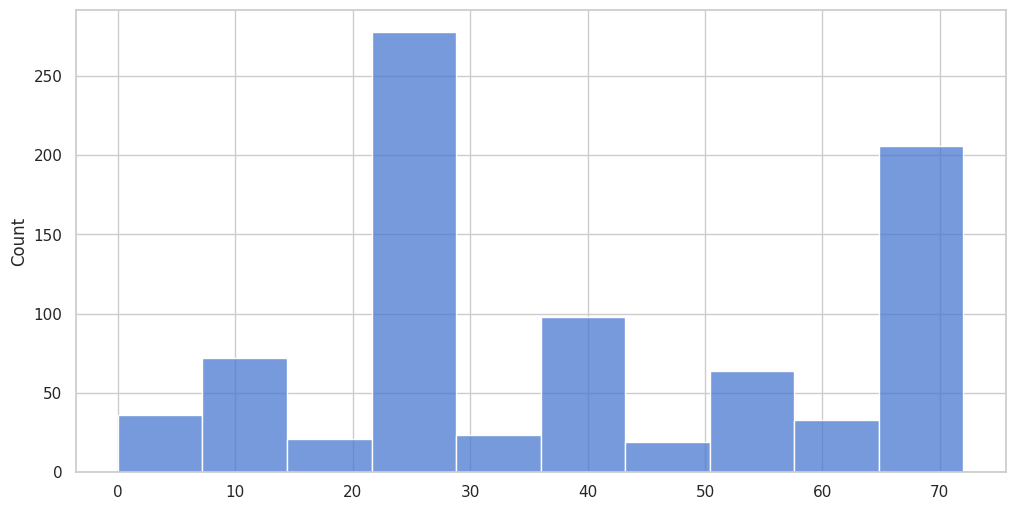

In [64]:
nn_idx = np.array(nn_idx)
sns.histplot(nn_idx, binwidth=7)

In [65]:
train['bins'] = pd.cut(nn_idx, 5)
complete_plot['bins'] = complete_plot.index.get_level_values(0).map(train['bins'])

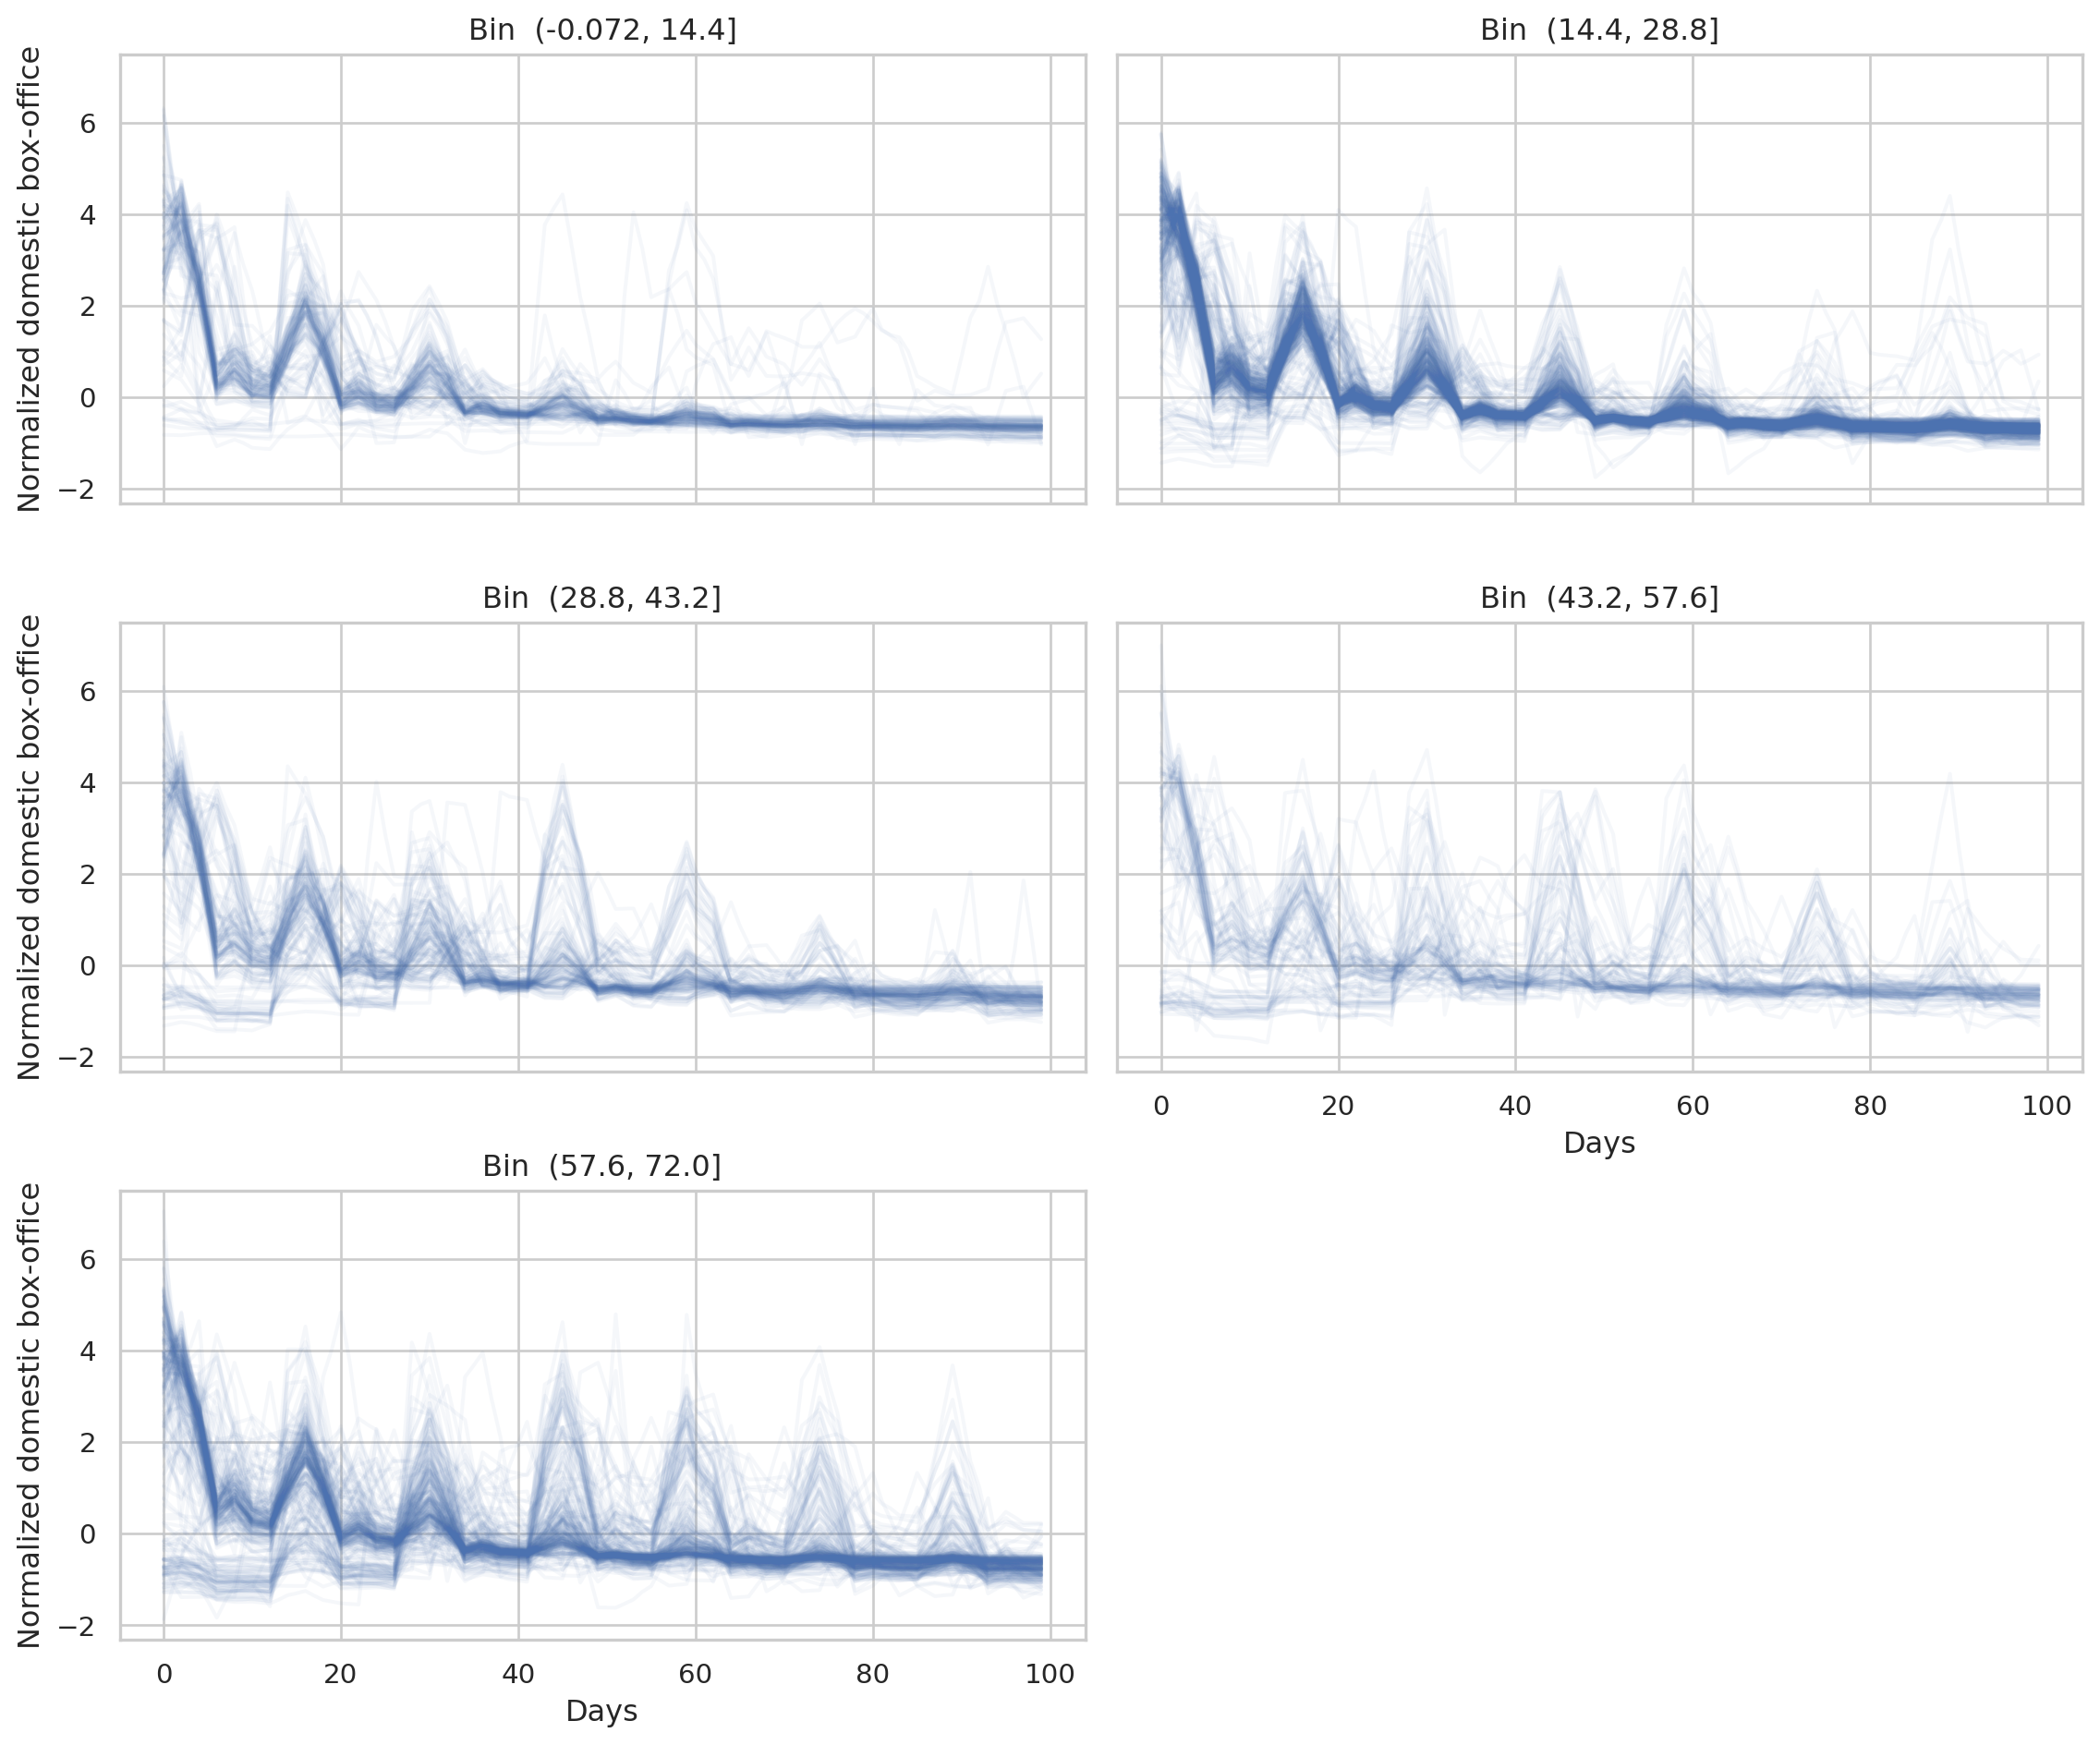

In [66]:
(
    so.Plot(complete_plot, x='time', y='value')
    .facet(col='bins', wrap=2)
    .add(so.Lines(alpha=.05), group='id', legend=False)
    .label(x='Days', y='Normalized domestic box-office', col="Bin ")
    .layout(size=(12, 10))
)

Looks like ths pattern is recurring at the start of the fifth week in movies of type 'Mad Max' and later for movies of type '12 Years a Slave'.

We also visualize the pattern on our medoids and then we call it a day.

In [67]:
mad_max_consensus = nn_idx[list(train.index).index(shape_medoids[1])]

In [68]:
twelve_years_consensus = nn_idx[list(train.index).index(shape_medoids[2])]

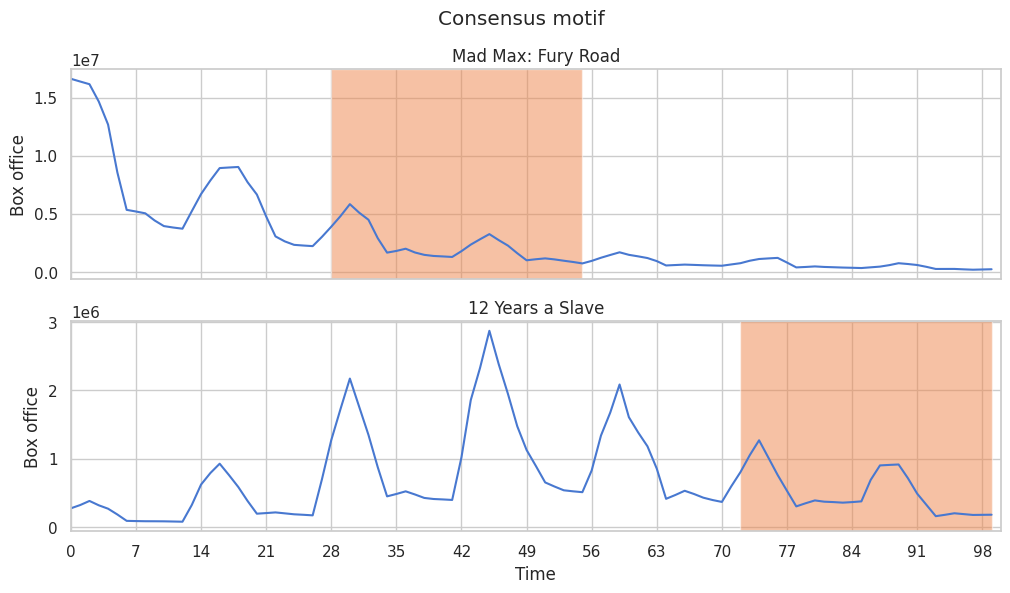

In [69]:
fig, axs = plt.subplots(2, sharex=True)
plt.suptitle('Consensus motif')

axs[0].set_title('Mad Max: Fury Road')
axs[1].set_title('12 Years a Slave')

axs[1].set_xlabel('Time')
axs[0].set_ylabel('Box office')
axs[1].set_ylabel('Box office')

axs[0].plot(mad_max)
axs[1].plot(twelve_years)

lower, upper = axs[0].get_ylim()
height = upper - lower
rect = Rectangle((mad_max_consensus, lower), m-1, height, facecolor='C1', alpha=.5)
axs[0].add_patch(rect)


lower, upper = axs[1].get_ylim()
height = upper - lower
rect = Rectangle((twelve_years_consensus, lower), m-1, height, facecolor='C1', alpha=.5)
axs[1].add_patch(rect)


plt.xticks(np.arange(0, 100, 7))
plt.xlim(0, 100)
plt.show()

This is good: keep this.